# Sign Language Recognition Baseline: HOG + SVM
This notebook establishes the mandatory baseline using Traditional Computer Vision (HOG) and Machine Learning (SVM).
Dataset used: **ASL-20-Words-Dataset-V1**.


In [3]:
"""
ASL-20 Words Sign Language Recognition using HOG + SVM Baseline
Dataset: ASL-20-Words-Dataset-V1
Author: Sign Language Recognition Tutorial

QUICK START GUIDE:
==================
1. Update DATASET_PATH to your actual path (e.g., "/kaggle/input/asl-20-words-dataset-v1/Full Data")
2. Adjust MAX_VIDEOS_PER_CLASS for faster training:
   - 50 videos/class  = ~1,000 total videos  (FAST - recommended for testing)
   - 100 videos/class = ~2,000 total videos  (MEDIUM - good balance)
   - 200 videos/class = ~4,000 total videos  (SLOW - better accuracy)
   - None = ALL videos (~8,500 total)       (VERY SLOW - best accuracy)
3. Run the script!

EXPECTED PROCESSING TIMES (approximate on GPU):
- 50 videos/class:   10-15 minutes
- 100 videos/class:  20-30 minutes
- 200 videos/class:  40-60 minutes
- ALL videos:        2-3 hours
"""

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import pickle
import random
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_recall_fscore_support,
                             top_k_accuracy_score)

# Mediapipe for hand detection
import mediapipe as mp

# ============================================================================
# CONFIGURATION
# ============================================================================

class Config:
    """Configuration parameters for the project"""
    # Paths - UPDATE THIS TO YOUR ACTUAL PATH
    DATASET_PATH = "/kaggle/input/asl-20-words-dataset-v1/Full Data"
    OUTPUT_DIR = "output_hog_svm"
    
    # Dataset sampling - REDUCE VIDEOS PER CLASS FOR FASTER TRAINING
    MAX_VIDEOS_PER_CLASS = 100  # Set to None to load all videos, or specify number (e.g., 50, 100)
    SHUFFLE_VIDEOS = True  # Randomly sample videos from each class
    
    # Video processing
    MAX_FRAMES = 30  # Maximum frames to extract per video
    FRAME_SIZE = (128, 128)  # Resize frames to this size
    
    # HOG parameters
    HOG_ORIENTATIONS = 9
    HOG_PIXELS_PER_CELL = (8, 8)
    HOG_CELLS_PER_BLOCK = (2, 2)
    HOG_BLOCK_NORM = 'L2-Hys'
    
    # Model parameters
    TEST_SIZE = 0.2
    VALIDATION_SIZE = 0.1
    RANDOM_STATE = 42
    
    # Hand detection
    USE_HAND_DETECTION = True  # Use MediaPipe to focus on hand region
    HAND_DETECTION_CONFIDENCE = 0.5

# Create output directory
os.makedirs(Config.OUTPUT_DIR, exist_ok=True)

# ============================================================================
# HAND DETECTION MODULE
# ============================================================================

class HandDetector:
    """Detect and crop hand regions using MediaPipe"""
    
    def __init__(self, confidence=0.5):
        self.mp_hands = mp.solutions.hands
        self.hands = self.mp_hands.Hands(
            static_image_mode=True,
            max_num_hands=2,
            min_detection_confidence=confidence
        )
    
    def detect_hand_region(self, frame):
        """
        Detect hand region and return cropped bounding box
        Returns: cropped_frame or original frame if no hand detected
        """
        h, w, _ = frame.shape
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = self.hands.process(rgb_frame)
        
        if results.multi_hand_landmarks:
            # Get bounding box for all detected hands
            all_x, all_y = [], []
            for hand_landmarks in results.multi_hand_landmarks:
                for landmark in hand_landmarks.landmark:
                    all_x.append(int(landmark.x * w))
                    all_y.append(int(landmark.y * h))
            
            # Add padding
            padding = 30
            x_min = max(0, min(all_x) - padding)
            x_max = min(w, max(all_x) + padding)
            y_min = max(0, min(all_y) - padding)
            y_max = min(h, max(all_y) + padding)
            
            # Crop hand region
            cropped = frame[y_min:y_max, x_min:x_max]
            
            if cropped.size > 0:
                return cropped
        
        return frame
    
    def close(self):
        self.hands.close()

# ============================================================================
# DATA LOADING AND PREPROCESSING
# ============================================================================

class VideoProcessor:
    """Process videos and extract frames"""
    
    def __init__(self, config):
        self.config = config
        self.hand_detector = HandDetector(config.HAND_DETECTION_CONFIDENCE) if config.USE_HAND_DETECTION else None
    
    def extract_frames(self, video_path, max_frames=None):
        """
        Extract frames from video
        Returns: list of preprocessed frames
        """
        if max_frames is None:
            max_frames = self.config.MAX_FRAMES
        
        cap = cv2.VideoCapture(video_path)
        frames = []
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        # Calculate frame sampling interval
        if frame_count > max_frames:
            interval = frame_count // max_frames
        else:
            interval = 1
        
        frame_idx = 0
        while len(frames) < max_frames:
            ret, frame = cap.read()
            if not ret:
                break
            
            if frame_idx % interval == 0:
                # Detect hand region if enabled
                if self.hand_detector:
                    frame = self.hand_detector.detect_hand_region(frame)
                
                # Resize frame
                frame = cv2.resize(frame, self.config.FRAME_SIZE)
                
                # Convert to grayscale for HOG
                gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                
                # Normalize
                gray = gray / 255.0
                
                frames.append(gray)
            
            frame_idx += 1
        
        cap.release()
        
        # Pad with zeros if not enough frames
        while len(frames) < max_frames:
            frames.append(np.zeros(self.config.FRAME_SIZE))
        
        return frames[:max_frames]
    
    def close(self):
        if self.hand_detector:
            self.hand_detector.close()

class DataLoader:
    """Load and organize dataset"""
    
    def __init__(self, config):
        self.config = config
        self.processor = VideoProcessor(config)
    
    def load_dataset(self):
        """
        Load videos from dataset with optional sampling per class
        Returns: X (features), y (labels), video_paths
        """
        dataset_path = Path(self.config.DATASET_PATH)
        
        if not dataset_path.exists():
            raise FileNotFoundError(f"Dataset path not found: {dataset_path}")
        
        video_paths = []
        labels = []
        
        # Get all class folders
        class_folders = sorted([f for f in dataset_path.iterdir() if f.is_dir()])
        
        print(f"Found {len(class_folders)} classes")
        
        if self.config.MAX_VIDEOS_PER_CLASS:
            print(f"Sampling mode: MAX {self.config.MAX_VIDEOS_PER_CLASS} videos per class")
            print(f"Random shuffle: {self.config.SHUFFLE_VIDEOS}")
        else:
            print("Loading ALL videos from each class")
        
        print("-" * 70)
        
        for class_folder in class_folders:
            class_name = class_folder.name
            video_files = list(class_folder.glob("*.mp4"))
            
            total_available = len(video_files)
            
            # Sample videos if MAX_VIDEOS_PER_CLASS is set
            if self.config.MAX_VIDEOS_PER_CLASS and total_available > self.config.MAX_VIDEOS_PER_CLASS:
                if self.config.SHUFFLE_VIDEOS:
                    import random
                    random.seed(self.config.RANDOM_STATE)
                    video_files = random.sample(video_files, self.config.MAX_VIDEOS_PER_CLASS)
                else:
                    video_files = video_files[:self.config.MAX_VIDEOS_PER_CLASS]
                
                print(f"Class '{class_name:15s}': {len(video_files):3d} videos (sampled from {total_available})")
            else:
                print(f"Class '{class_name:15s}': {len(video_files):3d} videos (all available)")
            
            for video_file in video_files:
                video_paths.append(str(video_file))
                labels.append(class_name)
        
        print("-" * 70)
        print(f"Total videos loaded: {len(video_paths)}")
        print(f"Total classes: {len(set(labels))}")
        print(f"Average videos per class: {len(video_paths) / len(set(labels)):.1f}")
        
        return video_paths, labels
    
    def process_videos(self, video_paths, labels):
        """
        Process all videos and extract frames
        Returns: processed frames and labels
        """
        all_frames = []
        valid_labels = []
        
        print("\nProcessing videos...")
        for video_path, label in tqdm(zip(video_paths, labels), total=len(video_paths)):
            try:
                frames = self.processor.extract_frames(video_path)
                all_frames.append(frames)
                valid_labels.append(label)
            except Exception as e:
                print(f"Error processing {video_path}: {e}")
                continue
        
        self.processor.close()
        return np.array(all_frames), np.array(valid_labels)

# ============================================================================
# FEATURE EXTRACTION
# ============================================================================

class HOGFeatureExtractor:
    """Extract HOG features from frames"""
    
    def __init__(self, config):
        self.config = config
        from skimage.feature import hog
        self.hog = hog
    
    def extract_hog_features(self, frame):
        """Extract HOG features from a single frame"""
        features = self.hog(
            frame,
            orientations=self.config.HOG_ORIENTATIONS,
            pixels_per_cell=self.config.HOG_PIXELS_PER_CELL,
            cells_per_block=self.config.HOG_CELLS_PER_BLOCK,
            block_norm=self.config.HOG_BLOCK_NORM,
            visualize=False,
            feature_vector=True
        )
        return features
    
    def extract_video_features(self, frames):
        """
        Extract HOG features from all frames in a video
        Returns: concatenated feature vector
        """
        video_features = []
        
        for frame in frames:
            frame_features = self.extract_hog_features(frame)
            video_features.append(frame_features)
        
        # Aggregate features (mean, max, std)
        video_features = np.array(video_features)
        
        # Statistical aggregation
        mean_features = np.mean(video_features, axis=0)
        max_features = np.max(video_features, axis=0)
        std_features = np.std(video_features, axis=0)
        
        # Concatenate all statistics
        combined_features = np.concatenate([mean_features, max_features, std_features])
        
        return combined_features
    
    def extract_all_features(self, all_frames):
        """Extract features from all videos"""
        print("\nExtracting HOG features...")
        features = []
        
        for frames in tqdm(all_frames):
            video_features = self.extract_video_features(frames)
            features.append(video_features)
        
        return np.array(features)

# ============================================================================
# MODEL TRAINING
# ============================================================================

class SignLanguageClassifier:
    """SVM-based classifier for sign language recognition"""
    
    def __init__(self, config):
        self.config = config
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        self.model = None
        self.best_params = None
    
    def prepare_data(self, X, y):
        """Encode labels and split data"""
        # Encode labels
        y_encoded = self.label_encoder.fit_transform(y)
        
        # Split data
        X_temp, X_test, y_temp, y_test = train_test_split(
            X, y_encoded,
            test_size=self.config.TEST_SIZE,
            random_state=self.config.RANDOM_STATE,
            stratify=y_encoded
        )
        
        X_train, X_val, y_train, y_val = train_test_split(
            X_temp, y_temp,
            test_size=self.config.VALIDATION_SIZE / (1 - self.config.TEST_SIZE),
            random_state=self.config.RANDOM_STATE,
            stratify=y_temp
        )
        
        # Scale features
        X_train = self.scaler.fit_transform(X_train)
        X_val = self.scaler.transform(X_val)
        X_test = self.scaler.transform(X_test)
        
        print(f"\nData split:")
        print(f"Train: {X_train.shape[0]} samples")
        print(f"Validation: {X_val.shape[0]} samples")
        print(f"Test: {X_test.shape[0]} samples")
        
        return (X_train, y_train), (X_val, y_val), (X_test, y_test)
    
    def train_svm(self, X_train, y_train, X_val, y_val):
        """Train SVM with grid search"""
        print("\nTraining SVM with Grid Search...")
        
        # Define parameter grid
        param_grid = {
            'C': [0.1, 1, 10, 100],
            'gamma': ['scale', 'auto', 0.001, 0.01],
            'kernel': ['rbf', 'linear']
        }
        
        # Grid search
        grid_search = GridSearchCV(
            SVC(random_state=self.config.RANDOM_STATE),
            param_grid,
            cv=3,
            scoring='accuracy',
            verbose=2,
            n_jobs=-1
        )
        
        grid_search.fit(X_train, y_train)
        
        self.model = grid_search.best_estimator_
        self.best_params = grid_search.best_params_
        
        print(f"\nBest parameters: {self.best_params}")
        
        # Validation accuracy
        val_acc = self.model.score(X_val, y_val)
        print(f"Validation Accuracy: {val_acc*100:.2f}%")
        
        return self.model
    
    def train_random_forest(self, X_train, y_train, X_val, y_val):
        """Train Random Forest as alternative"""
        print("\nTraining Random Forest...")
        
        param_grid = {
            'n_estimators': [100, 200, 300],
            'max_depth': [10, 20, 30, None],
            'min_samples_split': [2, 5, 10]
        }
        
        grid_search = GridSearchCV(
            RandomForestClassifier(random_state=self.config.RANDOM_STATE),
            param_grid,
            cv=3,
            scoring='accuracy',
            verbose=2,
            n_jobs=-1
        )
        
        grid_search.fit(X_train, y_train)
        
        rf_model = grid_search.best_estimator_
        
        val_acc = rf_model.score(X_val, y_val)
        print(f"\nRandom Forest Validation Accuracy: {val_acc*100:.2f}%")
        
        return rf_model
    
    def evaluate(self, X_test, y_test):
        """Comprehensive evaluation"""
        print("\n" + "="*70)
        print("EVALUATION RESULTS")
        print("="*70)
        
        # Predictions
        y_pred = self.model.predict(X_test)
        y_pred_proba = self.model.decision_function(X_test) if hasattr(self.model, 'decision_function') else None
        
        # Accuracy metrics
        accuracy = accuracy_score(y_test, y_pred)
        print(f"\n1. Classification Accuracy: {accuracy*100:.2f}%")
        
        # Top-k accuracy
        if y_pred_proba is not None:
            top_3_acc = top_k_accuracy_score(y_test, y_pred_proba, k=3)
            top_5_acc = top_k_accuracy_score(y_test, y_pred_proba, k=5)
            print(f"2. Top-3 Accuracy: {top_3_acc*100:.2f}%")
            print(f"3. Top-5 Accuracy: {top_5_acc*100:.2f}%")
        
        # Precision, Recall, F1
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_test, y_pred, average='weighted'
        )
        print(f"\n4. Weighted Precision: {precision*100:.2f}%")
        print(f"5. Weighted Recall: {recall*100:.2f}%")
        print(f"6. Weighted F1-Score: {f1*100:.2f}%")
        
        # Per-class metrics
        print("\n7. Per-Class Performance:")
        print("-" * 70)
        class_report = classification_report(
            y_test, y_pred,
            target_names=self.label_encoder.classes_,
            digits=3
        )
        print(class_report)
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        
        return {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'confusion_matrix': cm,
            'y_pred': y_pred,
            'y_test': y_test,
            'classification_report': class_report
        }
    
    def save_model(self, filepath):
        """Save trained model"""
        model_data = {
            'model': self.model,
            'scaler': self.scaler,
            'label_encoder': self.label_encoder,
            'best_params': self.best_params
        }
        with open(filepath, 'wb') as f:
            pickle.dump(model_data, f)
        print(f"\nModel saved to: {filepath}")
    
    def load_model(self, filepath):
        """Load trained model"""
        with open(filepath, 'rb') as f:
            model_data = pickle.load(f)
        self.model = model_data['model']
        self.scaler = model_data['scaler']
        self.label_encoder = model_data['label_encoder']
        self.best_params = model_data['best_params']
        print(f"\nModel loaded from: {filepath}")

# ============================================================================
# VISUALIZATION
# ============================================================================

class ResultVisualizer:
    """Visualize results and metrics"""
    
    @staticmethod
    def plot_confusion_matrix(cm, class_names, output_path):
        """Plot confusion matrix"""
        plt.figure(figsize=(14, 12))
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Count'}
        )
        plt.xlabel('Predicted Label', fontsize=12)
        plt.ylabel('True Label', fontsize=12)
        plt.title('Confusion Matrix - HOG + SVM Sign Language Recognition', fontsize=14)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"Confusion matrix saved to: {output_path}")
        plt.close()
    
    @staticmethod
    def plot_metrics_summary(results, output_path):
        """Plot summary of key metrics"""
        metrics = {
            'Accuracy': results['accuracy'] * 100,
            'Precision': results['precision'] * 100,
            'Recall': results['recall'] * 100,
            'F1-Score': results['f1_score'] * 100
        }
        
        plt.figure(figsize=(10, 6))
        bars = plt.bar(metrics.keys(), metrics.values(), color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'])
        plt.ylabel('Percentage (%)', fontsize=12)
        plt.title('Performance Metrics Summary - HOG + SVM', fontsize=14)
        plt.ylim(0, 100)
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}%',
                    ha='center', va='bottom', fontsize=11)
        
        plt.tight_layout()
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"Metrics summary saved to: {output_path}")
        plt.close()
    
    @staticmethod
    def save_results_report(results, classifier, output_path):
        """Save detailed results report"""
        with open(output_path, 'w') as f:
            f.write("="*70 + "\n")
            f.write("SIGN LANGUAGE RECOGNITION - HOG + SVM BASELINE\n")
            f.write("="*70 + "\n\n")
            
            f.write("CONFIGURATION:\n")
            f.write(f"- Frame Size: {Config.FRAME_SIZE}\n")
            f.write(f"- Max Frames per Video: {Config.MAX_FRAMES}\n")
            f.write(f"- HOG Orientations: {Config.HOG_ORIENTATIONS}\n")
            f.write(f"- Pixels per Cell: {Config.HOG_PIXELS_PER_CELL}\n")
            f.write(f"- Cells per Block: {Config.HOG_CELLS_PER_BLOCK}\n")
            f.write(f"- Hand Detection: {Config.USE_HAND_DETECTION}\n\n")
            
            if classifier.best_params:
                f.write("BEST MODEL PARAMETERS:\n")
                for param, value in classifier.best_params.items():
                    f.write(f"- {param}: {value}\n")
                f.write("\n")
            
            f.write("PERFORMANCE METRICS:\n")
            f.write(f"- Classification Accuracy: {results['accuracy']*100:.2f}%\n")
            f.write(f"- Weighted Precision: {results['precision']*100:.2f}%\n")
            f.write(f"- Weighted Recall: {results['recall']*100:.2f}%\n")
            f.write(f"- Weighted F1-Score: {results['f1_score']*100:.2f}%\n\n")
            
            f.write("DETAILED CLASSIFICATION REPORT:\n")
            f.write("-"*70 + "\n")
            f.write(results['classification_report'])
            f.write("\n")
        
        print(f"Results report saved to: {output_path}")

2025-12-10 00:58:55.366864: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765328335.900419      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765328336.041144      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
pip install mediapipe

INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 43.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 24.3 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.0
    Uninstalling protobuf-6.33.0:
      Successfully uninstalled protobuf-6.33.0
  Attempting uninstall: opencv-contrib-python
    Found existing installation: opencv-contrib-python 4.12.0.88
    Uninstalling opencv-contrib-python-4.12.0.88:
      Successfully uninstalled opencv-contrib-python-4.12.0.88
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 re

In [4]:
    print("="*70)
    print("ASL-20 WORDS SIGN LANGUAGE RECOGNITION")
    print("Baseline: HOG + SVM")
    print("="*70 + "\n")
    
    # Initialize configuration
    config = Config()

ASL-20 WORDS SIGN LANGUAGE RECOGNITION
Baseline: HOG + SVM



In [6]:
    print("CONFIGURATION SUMMARY:")
    print("-"*70)
    print(f"Dataset Path: {config.DATASET_PATH}")
    print(f"Output Directory: {config.OUTPUT_DIR}")
    print(f"Max Videos Per Class: {config.MAX_VIDEOS_PER_CLASS if config.MAX_VIDEOS_PER_CLASS else 'ALL'}")
    print(f"Max Frames Per Video: {config.MAX_FRAMES}")
    print(f"Frame Size: {config.FRAME_SIZE}")
    print(f"Hand Detection: {config.USE_HAND_DETECTION}")
    print(f"Test Split: {config.TEST_SIZE * 100:.0f}%")
    print("="*70 + "\n")
    
    import time
    start_time = time.time()

CONFIGURATION SUMMARY:
----------------------------------------------------------------------
Dataset Path: /kaggle/input/asl-20-words-dataset-v1/Full Data
Output Directory: output_hog_svm
Max Videos Per Class: 100
Max Frames Per Video: 30
Frame Size: (128, 128)
Hand Detection: True
Test Split: 20%



## Step 1: Loading Dataset
Load the ASL-20 dataset from the directory structure into memory.


In [7]:
    print("STEP 1: Loading Dataset")
    print("-"*70)
    step1_start = time.time()
    loader = DataLoader(config)
    video_paths, labels = loader.load_dataset()
    step1_time = time.time() - step1_start
    print(f"\n⏱️  Step 1 completed in {step1_time:.1f} seconds")

STEP 1: Loading Dataset
----------------------------------------------------------------------
Found 20 classes
Sampling mode: MAX 100 videos per class
Random shuffle: True
----------------------------------------------------------------------
Class 'baby           ': 100 videos (sampled from 430)
Class 'eat            ': 100 videos (sampled from 440)
Class 'father         ': 100 videos (sampled from 452)
Class 'finish         ': 100 videos (sampled from 440)
Class 'good           ': 100 videos (sampled from 436)
Class 'happy          ': 100 videos (sampled from 445)
Class 'hear           ': 100 videos (sampled from 433)
Class 'house          ': 100 videos (sampled from 421)
Class 'important      ': 100 videos (sampled from 446)
Class 'love           ': 100 videos (sampled from 435)
Class 'mall           ': 100 videos (sampled from 414)


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1765328412.390474     144 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1765328412.422085     146 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Class 'me             ': 100 videos (sampled from 430)
Class 'mosque         ': 100 videos (sampled from 427)
Class 'mother         ': 100 videos (sampled from 406)
Class 'normal         ': 100 videos (sampled from 410)
Class 'sad            ': 100 videos (sampled from 420)
Class 'stop           ': 100 videos (sampled from 426)
Class 'thanks         ': 100 videos (sampled from 412)
Class 'thinking       ': 100 videos (sampled from 366)
Class 'worry          ': 100 videos (sampled from 409)
----------------------------------------------------------------------
Total videos loaded: 2000
Total classes: 20
Average videos per class: 100.0

⏱️  Step 1 completed in 0.4 seconds


### Data Exploration: Class Distribution
Visualize the number of samples per class to check for class imbalance.



VISUALIZATION 2: Dataset Class Distribution
Class distribution saved to: output_hog_svm/class_distribution.png


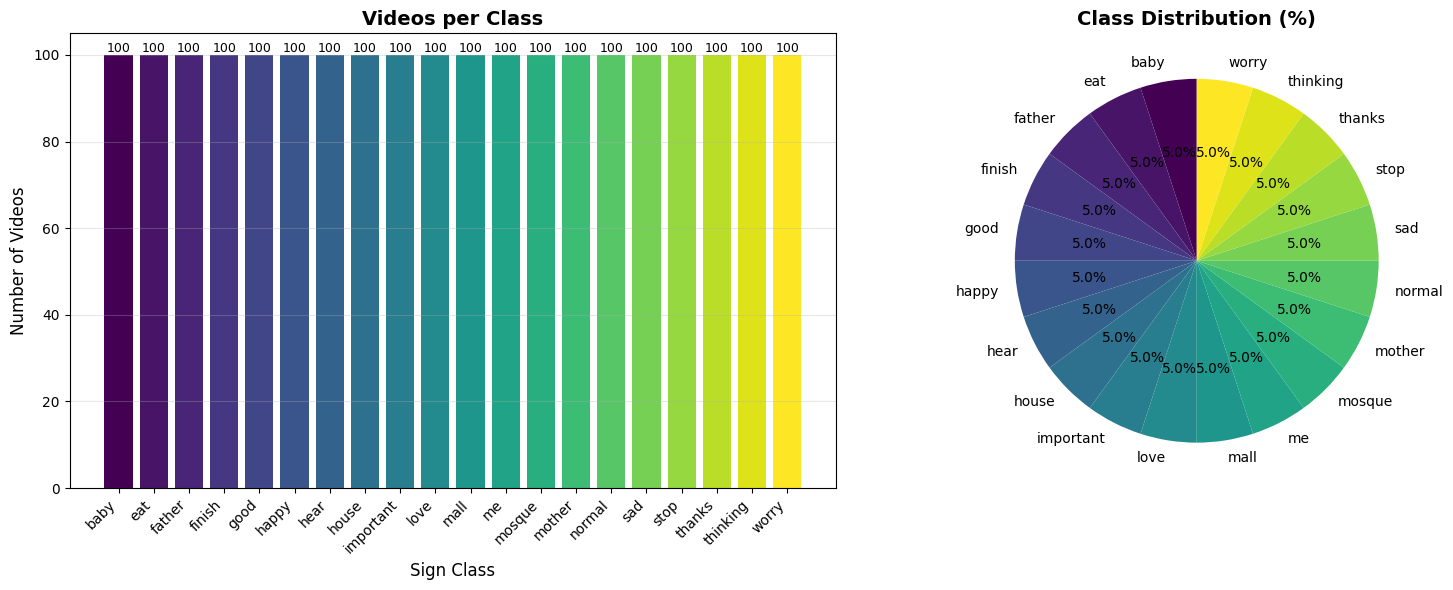

In [18]:
# ============================================================================
# VISUALIZATION 2: Class Distribution (After Step 1)
# Add this cell after loading the dataset
# ============================================================================

print("\n" + "="*70)
print("VISUALIZATION 2: Dataset Class Distribution")
print("="*70)

# Count samples per class
class_counts = pd.Series(labels).value_counts().sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
colors = plt.cm.viridis(np.linspace(0, 1, len(class_counts)))
bars = ax1.bar(range(len(class_counts)), class_counts.values, color=colors)
ax1.set_xlabel('Sign Class', fontsize=12)
ax1.set_ylabel('Number of Videos', fontsize=12)
ax1.set_title('Videos per Class', fontsize=14, fontweight='bold')
ax1.set_xticks(range(len(class_counts)))
ax1.set_xticklabels(class_counts.index, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=9)

# Pie chart
ax2.pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
ax2.set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(config.OUTPUT_DIR, 'class_distribution.png'), 
            dpi=200, bbox_inches='tight')
print(f"Class distribution saved to: {config.OUTPUT_DIR}/class_distribution.png")
plt.show()

## Step 2: Processing Videos
Extract frames and apply preprocessing (resizing, normalization).


In [8]:
    print("\n" + "="*70)
    print("STEP 2: Processing Videos")
    print("-"*70)
    step2_start = time.time()
    all_frames, all_labels = loader.process_videos(video_paths, labels)
    step2_time = time.time() - step2_start
    
    print(f"\nProcessed: {len(all_frames)} videos")
    print(f"Frame shape per video: {all_frames[0].shape}")
    print(f"⏱️  Step 2 completed in {step2_time:.1f} seconds ({step2_time/60:.1f} minutes)")


STEP 2: Processing Videos
----------------------------------------------------------------------

Processing videos...


  8%|▊         | 159/2000 [04:19<43:54,  1.43s/it] [h264 @ 0x2d2af280] Invalid NAL unit size (9616 > 8211).
[h264 @ 0x2d2af280] Error splitting the input into NAL units.
 13%|█▎        | 251/2000 [06:45<46:50,  1.61s/it]  [h264 @ 0x3419d5c0] Invalid NAL unit size (15412 > 6576).
[h264 @ 0x3419d5c0] Error splitting the input into NAL units.
 14%|█▍        | 282/2000 [07:33<44:41,  1.56s/it][h264 @ 0x45f427c0] Invalid NAL unit size (12498 > 12021).
[h264 @ 0x45f427c0] Error splitting the input into NAL units.
 17%|█▋        | 337/2000 [09:03<43:08,  1.56s/it]  [h264 @ 0x60b92700] Invalid NAL unit size (14807 > 12329).
[h264 @ 0x60b92700] Error splitting the input into NAL units.
 18%|█▊        | 357/2000 [09:38<46:32,  1.70s/it]  [h264 @ 0x3af0c8c0] Invalid NAL unit size (13614 > 13085).
[h264 @ 0x3af0c8c0] Error splitting the input into NAL units.
 20%|█▉        | 391/2000 [10:30<42:03,  1.57s/it][h264 @ 0x45f427c0] Invalid NAL unit size (12676 > 9233).
[h264 @ 0x45f427c0] Error splitti


Processed: 2000 videos
Frame shape per video: (30, 128, 128)
⏱️  Step 2 completed in 2996.7 seconds (49.9 minutes)



VISUALIZATION 1: Sample Video Frames
Sample frames visualization saved to: output_hog_svm/sample_frames.png


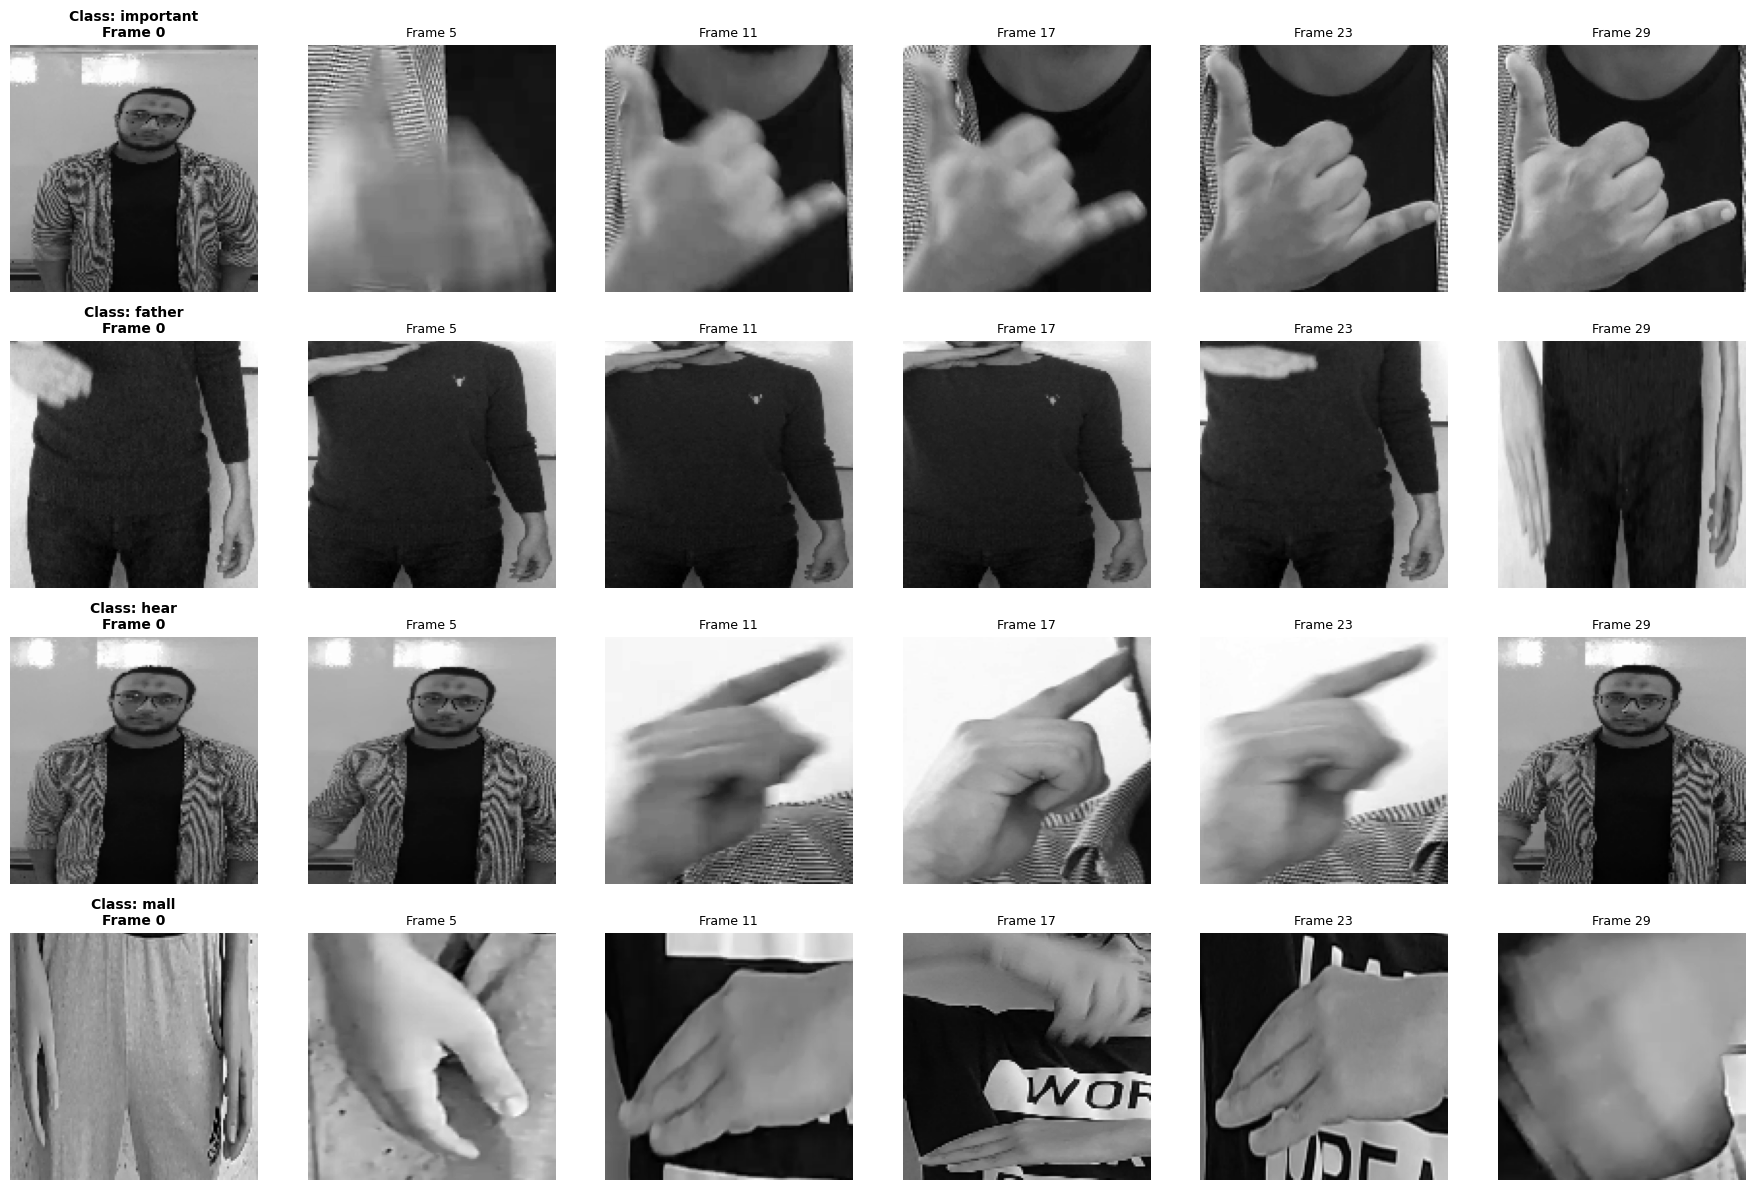

In [17]:
# ============================================================================
# VISUALIZATION CODE TO ADD TO YOUR NOTEBOOK
# Add these cells after each corresponding step in your notebook
# ============================================================================

# ============================================================================
# VISUALIZATION 1: Sample Frames from Videos (After Step 2)
# Add this cell after video processing is complete
# ============================================================================

print("\n" + "="*70)
print("VISUALIZATION 1: Sample Video Frames")
print("="*70)

import random

# Select random samples from different classes
unique_classes = np.unique(all_labels)
n_classes_to_show = min(4, len(unique_classes))
n_frames_per_video = 6

fig, axes = plt.subplots(n_classes_to_show, n_frames_per_video, 
                         figsize=(18, 3*n_classes_to_show))

for i, class_name in enumerate(random.sample(list(unique_classes), n_classes_to_show)):
    # Get a random video from this class
    class_indices = np.where(all_labels == class_name)[0]
    video_idx = random.choice(class_indices)
    frames = all_frames[video_idx]
    
    # Select evenly spaced frames
    frame_indices = np.linspace(0, len(frames)-1, n_frames_per_video, dtype=int)
    
    for j, frame_idx in enumerate(frame_indices):
        ax = axes[i, j] if n_classes_to_show > 1 else axes[j]
        ax.imshow(frames[frame_idx], cmap='gray')
        ax.axis('off')
        if j == 0:
            ax.set_title(f'Class: {class_name}\nFrame {frame_idx}', 
                        fontsize=10, fontweight='bold')
        else:
            ax.set_title(f'Frame {frame_idx}', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(config.OUTPUT_DIR, 'sample_frames.png'), 
            dpi=200, bbox_inches='tight')
print(f"Sample frames visualization saved to: {config.OUTPUT_DIR}/sample_frames.png")
plt.show()

### Save Processed Data
Checkpoint the processed frames to disk for faster reloading.


In [11]:
np.savez_compressed(os.path.join("/kaggle/working/", "processed_videos.npz"),
                    X=all_frames, y=all_labels)

## Step 3: Feature Extraction (HOG)
Extract Histogram of Oriented Gradients (HOG) features from the processed frames.


In [12]:
    print("\n" + "="*70)
    print("STEP 3: Feature Extraction")
    print("-"*70)
    step3_start = time.time()
    feature_extractor = HOGFeatureExtractor(config)
    X = feature_extractor.extract_all_features(all_frames)
    step3_time = time.time() - step3_start


STEP 3: Feature Extraction
----------------------------------------------------------------------

Extracting HOG features...


100%|██████████| 2000/2000 [05:57<00:00,  5.59it/s]


### Visualization: HOG Features
Visualize what the HOG descriptors look like.



VISUALIZATION 3: HOG Features Visualization
HOG features visualization saved to: output_hog_svm/hog_features.png


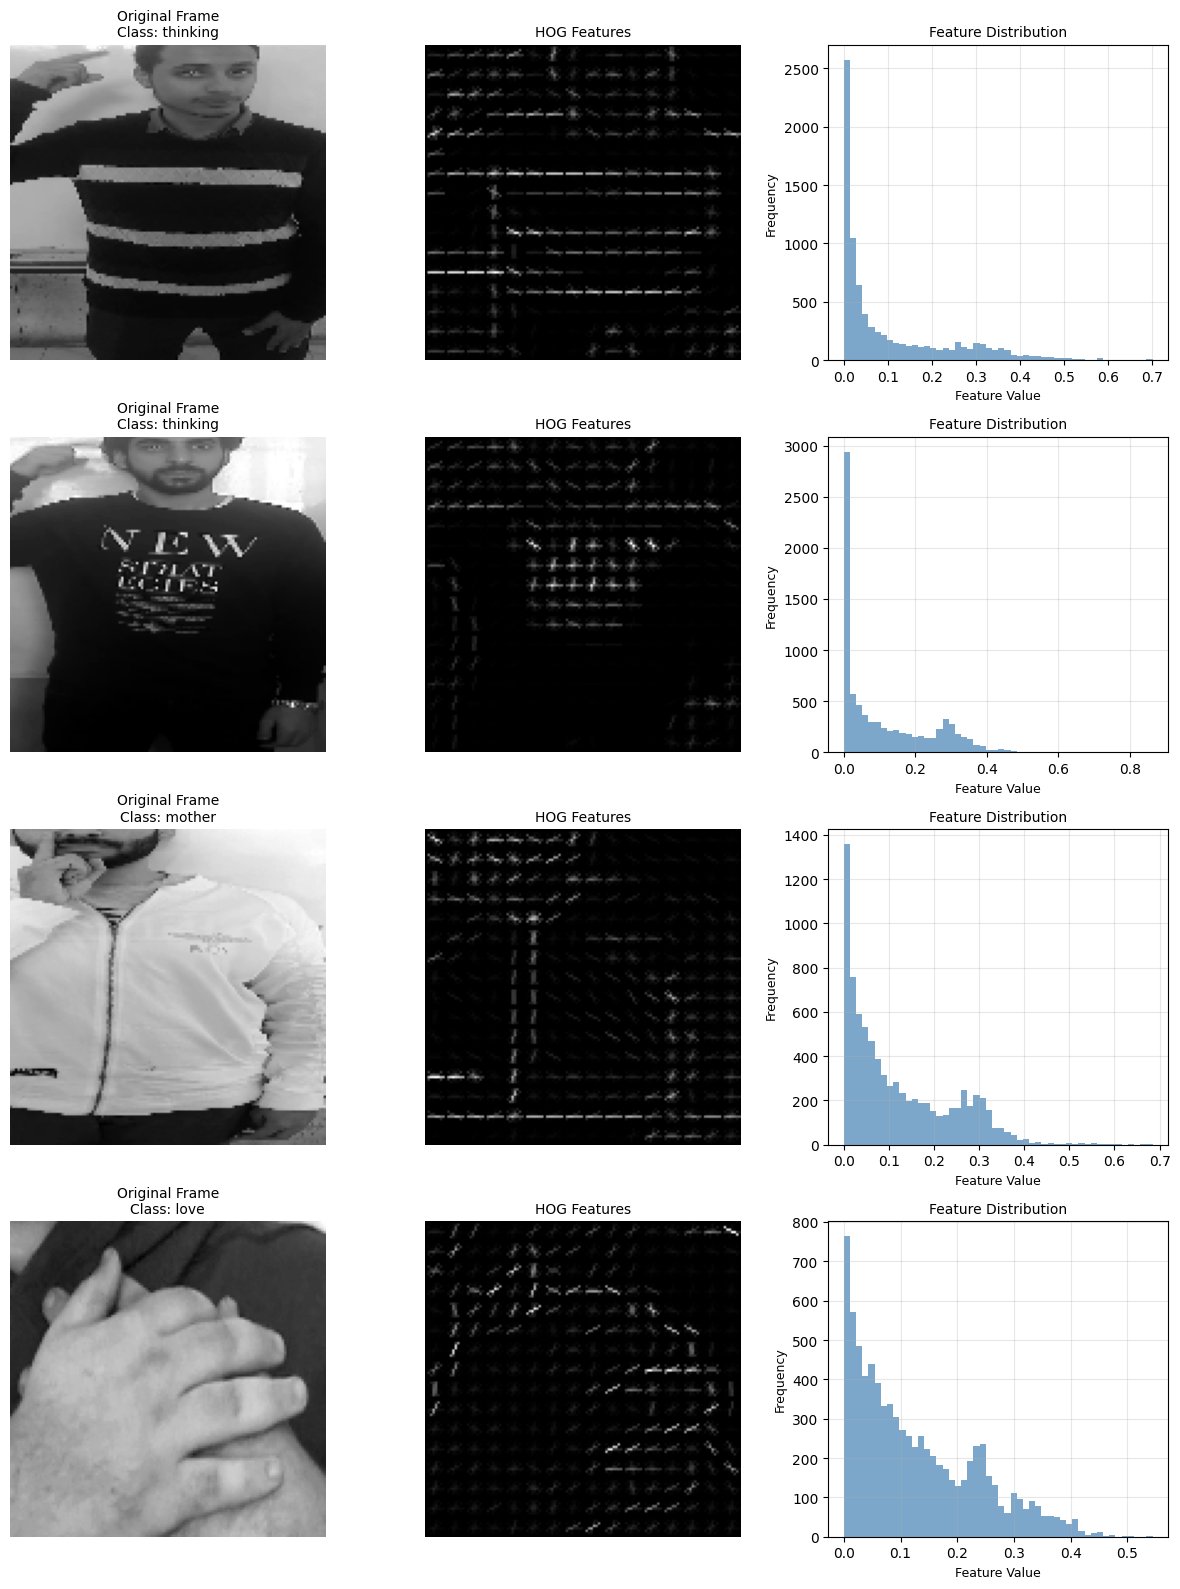

In [19]:
# ============================================================================
# VISUALIZATION 3: HOG Features Visualization (After Step 3)
# Add this cell after feature extraction
# ============================================================================

print("\n" + "="*70)
print("VISUALIZATION 3: HOG Features Visualization")
print("="*70)

from skimage.feature import hog

# Select a few random frames to visualize HOG
n_samples = 4
sample_indices = random.sample(range(len(all_frames)), n_samples)

fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4*n_samples))

for i, idx in enumerate(sample_indices):
    # Get a middle frame from the video
    frame = all_frames[idx][15]  # Middle frame
    label = all_labels[idx]
    
    # Compute HOG with visualization
    hog_features, hog_image = hog(
        frame,
        orientations=config.HOG_ORIENTATIONS,
        pixels_per_cell=config.HOG_PIXELS_PER_CELL,
        cells_per_block=config.HOG_CELLS_PER_BLOCK,
        block_norm=config.HOG_BLOCK_NORM,
        visualize=True,
        feature_vector=True
    )
    
    # Original frame
    axes[i, 0].imshow(frame, cmap='gray')
    axes[i, 0].set_title(f'Original Frame\nClass: {label}', fontsize=10)
    axes[i, 0].axis('off')
    
    # HOG visualization
    axes[i, 1].imshow(hog_image, cmap='gray')
    axes[i, 1].set_title('HOG Features', fontsize=10)
    axes[i, 1].axis('off')
    
    # Feature vector histogram
    axes[i, 2].hist(hog_features, bins=50, color='steelblue', alpha=0.7)
    axes[i, 2].set_title('Feature Distribution', fontsize=10)
    axes[i, 2].set_xlabel('Feature Value', fontsize=9)
    axes[i, 2].set_ylabel('Frequency', fontsize=9)
    axes[i, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.OUTPUT_DIR, 'hog_features.png'), 
            dpi=200, bbox_inches='tight')
print(f"HOG features visualization saved to: {config.OUTPUT_DIR}/hog_features.png")
plt.show()

### Visualization: Feature Space Analysis
Analyze the extracted feature vectors.



VISUALIZATION 4: Feature Space Analysis (PCA)
Feature space visualization saved to: output_hog_svm/feature_space_pca.png


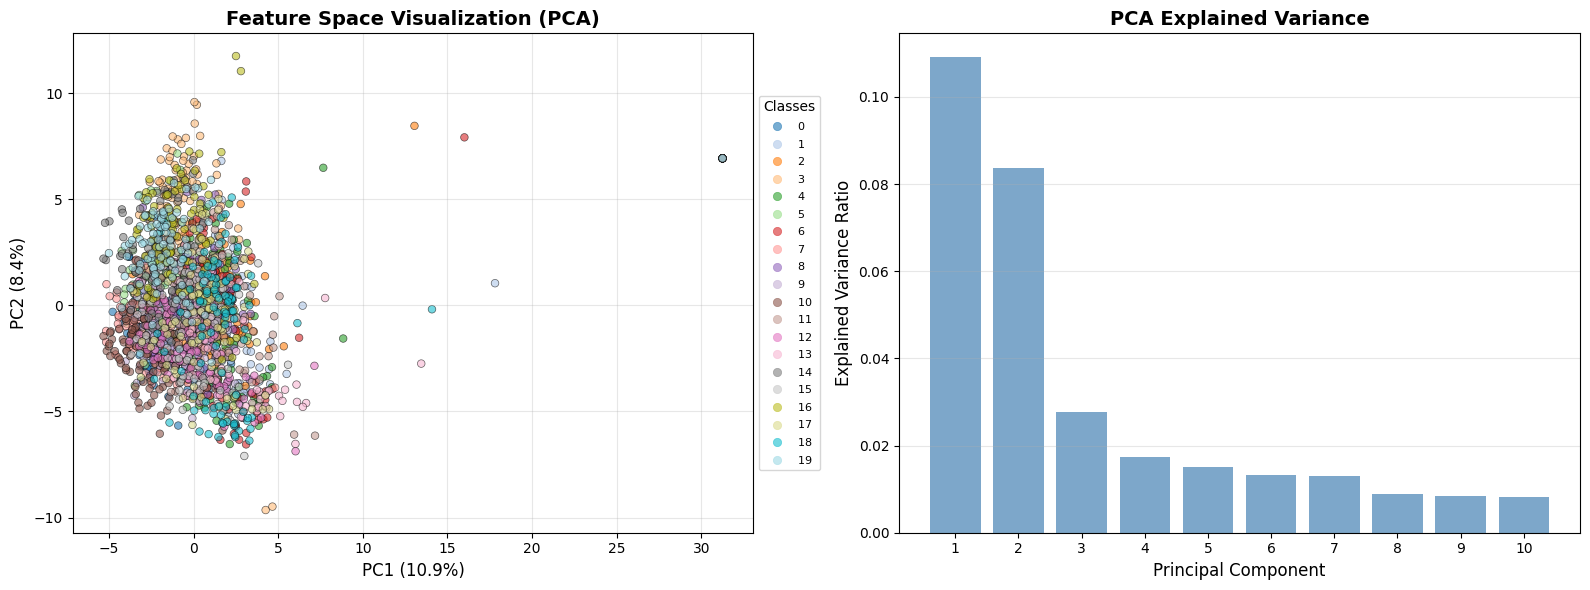

In [20]:
# ============================================================================
# VISUALIZATION 4: Feature Space Analysis (After Step 3)
# Add this cell after feature extraction
# ============================================================================

print("\n" + "="*70)
print("VISUALIZATION 4: Feature Space Analysis (PCA)")
print("="*70)

from sklearn.decomposition import PCA

# Perform PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create color map for classes
label_encoder_viz = LabelEncoder()
y_encoded_viz = label_encoder_viz.fit_transform(all_labels)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot with all points
scatter = ax1.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=y_encoded_viz, cmap='tab20',
                     alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax1.set_title('Feature Space Visualization (PCA)', fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3)

# Add legend
legend1 = ax1.legend(*scatter.legend_elements(num=len(label_encoder_viz.classes_)),
                    loc="center left", bbox_to_anchor=(1, 0.5),
                    title="Classes", fontsize=8)

# Explained variance plot
ax2.bar(range(1, 11), 
       PCA(n_components=10).fit(X).explained_variance_ratio_[:10],
       color='steelblue', alpha=0.7)
ax2.set_xlabel('Principal Component', fontsize=12)
ax2.set_ylabel('Explained Variance Ratio', fontsize=12)
ax2.set_title('PCA Explained Variance', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.set_xticks(range(1, 11))

plt.tight_layout()
plt.savefig(os.path.join(config.OUTPUT_DIR, 'feature_space_pca.png'), 
            dpi=200, bbox_inches='tight')
print(f"Feature space visualization saved to: {config.OUTPUT_DIR}/feature_space_pca.png")
plt.show()

In [13]:
    print(f"\nFeature vector shape: {X.shape}")
    print(f"Feature dimension per video: {X.shape[1]}")
    print(f"⏱️  Step 3 completed in {step3_time:.1f} seconds")
    
    print("\n" + "="*70)
    print("STEP 4: Model Training")
    print("-"*70)
    step4_start = time.time()
    classifier = SignLanguageClassifier(config)
    
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = classifier.prepare_data(X, all_labels)


Feature vector shape: (2000, 24300)
Feature dimension per video: 24300
⏱️  Step 3 completed in 358.1 seconds

STEP 4: Model Training
----------------------------------------------------------------------

Data split:
Train: 1400 samples
Validation: 200 samples
Test: 400 samples


## Step 4: Model Training (SVM)
Train a Support Vector Machine on the extracted HOG features.


In [14]:
    classifier.train_svm(X_train, y_train, X_val, y_val)
    step4_time = time.time() - step4_start
    print(f"\n⏱️  Step 4 completed in {step4_time:.1f} seconds ({step4_time/60:.1f} minutes)")



Training SVM with Grid Search...
Fitting 3 folds for each of 32 candidates, totalling 96 fits

Best parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Validation Accuracy: 86.50%

⏱️  Step 4 completed in 1296.6 seconds (21.6 minutes)


## Step 5: Model Evaluation
Evaluate the trained model on the validation/test set.


In [15]:
    print("\n" + "="*70)
    print("STEP 5: Model Evaluation")
    print("-"*70)
    step5_start = time.time()
    results = classifier.evaluate(X_test, y_test)
    step5_time = time.time() - step5_start
    print(f"\n⏱️  Step 5 completed in {step5_time:.1f} seconds")


STEP 5: Model Evaluation
----------------------------------------------------------------------

EVALUATION RESULTS

1. Classification Accuracy: 84.75%
2. Top-3 Accuracy: 94.00%
3. Top-5 Accuracy: 96.50%

4. Weighted Precision: 85.56%
5. Weighted Recall: 84.75%
6. Weighted F1-Score: 84.61%

7. Per-Class Performance:
----------------------------------------------------------------------
              precision    recall  f1-score   support

        baby      1.000     1.000     1.000        20
         eat      0.762     0.800     0.780        20
      father      0.882     0.750     0.811        20
      finish      0.938     0.750     0.833        20
        good      0.789     0.750     0.769        20
       happy      0.944     0.850     0.895        20
        hear      0.750     0.450     0.563        20
       house      0.941     0.800     0.865        20
   important      0.895     0.850     0.872        20
        love      1.000     1.000     1.000        20
        mall   

### Visualization: Prediction Examples
Show sample predictions alongside their ground truth labels.



VISUALIZATION 5: Sample Predictions
Prediction samples saved to: output_hog_svm/prediction_samples.png


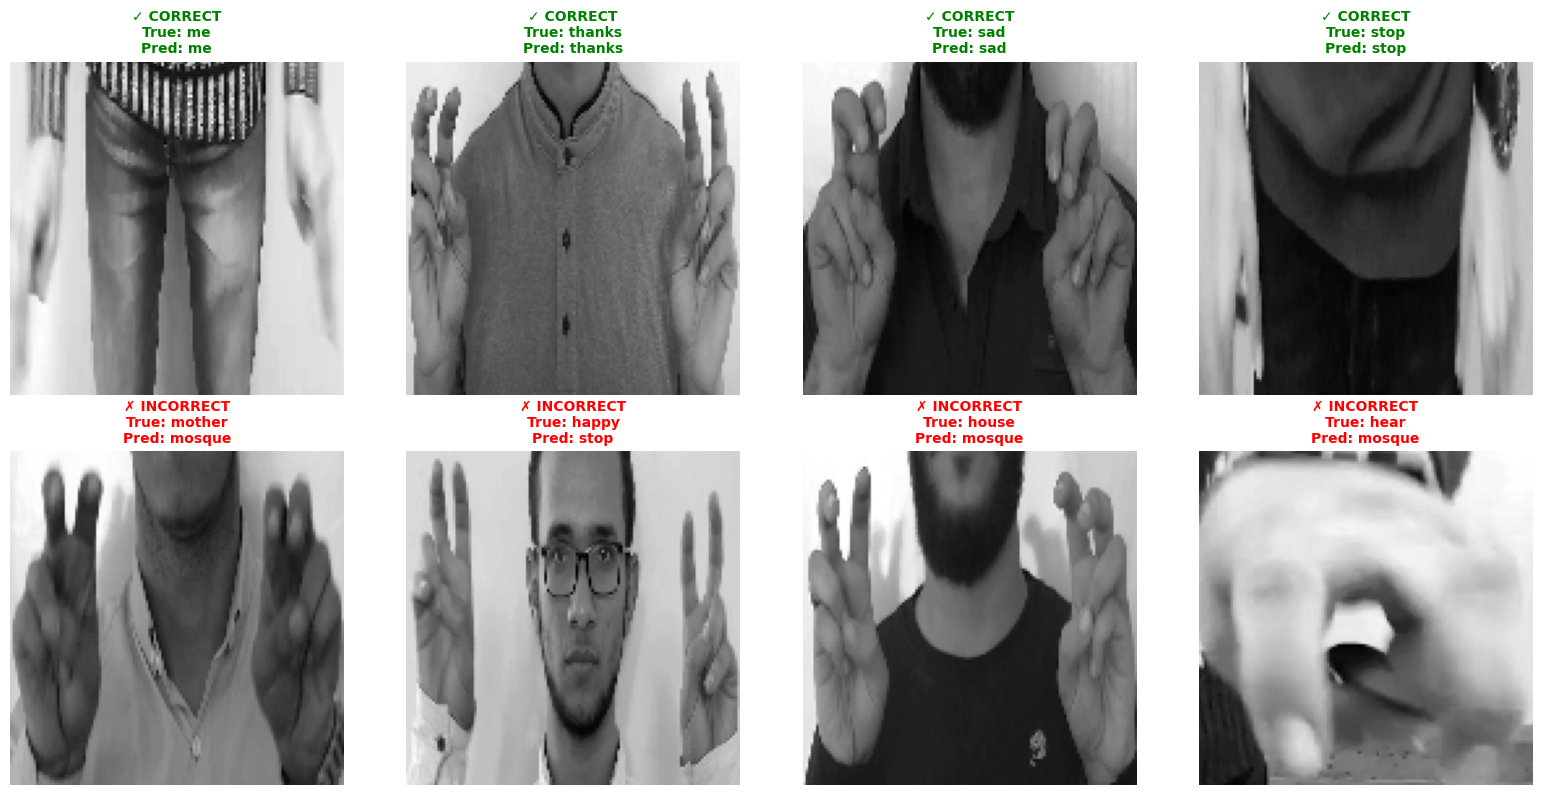

In [21]:
# ============================================================================
# VISUALIZATION 5: Prediction Examples (After Step 5)
# Add this cell after model evaluation
# ============================================================================

print("\n" + "="*70)
print("VISUALIZATION 5: Sample Predictions")
print("="*70)

# Get predictions on test set
y_pred = results['y_pred']
y_true = results['y_test']

# Find correct and incorrect predictions
correct_mask = (y_pred == y_true)
correct_indices = np.where(correct_mask)[0]
incorrect_indices = np.where(~correct_mask)[0]

# Select samples
n_correct = min(4, len(correct_indices))
n_incorrect = min(4, len(incorrect_indices))

fig, axes = plt.subplots(2, max(n_correct, n_incorrect), 
                         figsize=(4*max(n_correct, n_incorrect), 8))

# Get test indices (need to track which videos are in test set)
test_size = int(len(all_frames) * config.TEST_SIZE)
test_video_indices = list(range(len(all_frames) - test_size, len(all_frames)))

# Show correct predictions
for i in range(n_correct):
    idx = correct_indices[i]
    video_idx = test_video_indices[idx]
    
    # Show middle frame
    frame = all_frames[video_idx][15]
    true_label = classifier.label_encoder.inverse_transform([y_true[idx]])[0]
    pred_label = classifier.label_encoder.inverse_transform([y_pred[idx]])[0]
    
    ax = axes[0, i] if n_correct > 1 else axes[0]
    ax.imshow(frame, cmap='gray')
    ax.set_title(f'✓ CORRECT\nTrue: {true_label}\nPred: {pred_label}',
                fontsize=10, color='green', fontweight='bold')
    ax.axis('off')

# Show incorrect predictions
for i in range(n_incorrect):
    idx = incorrect_indices[i]
    video_idx = test_video_indices[idx]
    
    # Show middle frame
    frame = all_frames[video_idx][15]
    true_label = classifier.label_encoder.inverse_transform([y_true[idx]])[0]
    pred_label = classifier.label_encoder.inverse_transform([y_pred[idx]])[0]
    
    ax = axes[1, i] if n_incorrect > 1 else axes[1]
    ax.imshow(frame, cmap='gray')
    ax.set_title(f'✗ INCORRECT\nTrue: {true_label}\nPred: {pred_label}',
                fontsize=10, color='red', fontweight='bold')
    ax.axis('off')

# Hide unused subplots
for i in range(n_correct, max(n_correct, n_incorrect)):
    axes[0, i].axis('off')
for i in range(n_incorrect, max(n_correct, n_incorrect)):
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(config.OUTPUT_DIR, 'prediction_samples.png'), 
            dpi=200, bbox_inches='tight')
print(f"Prediction samples saved to: {config.OUTPUT_DIR}/prediction_samples.png")
plt.show()

### Visualization: Per-Class Performance
Plot precision, recall, and F1-score for each class.



VISUALIZATION 6: Per-Class Performance Analysis
Per-class performance saved to: output_hog_svm/per_class_performance.png


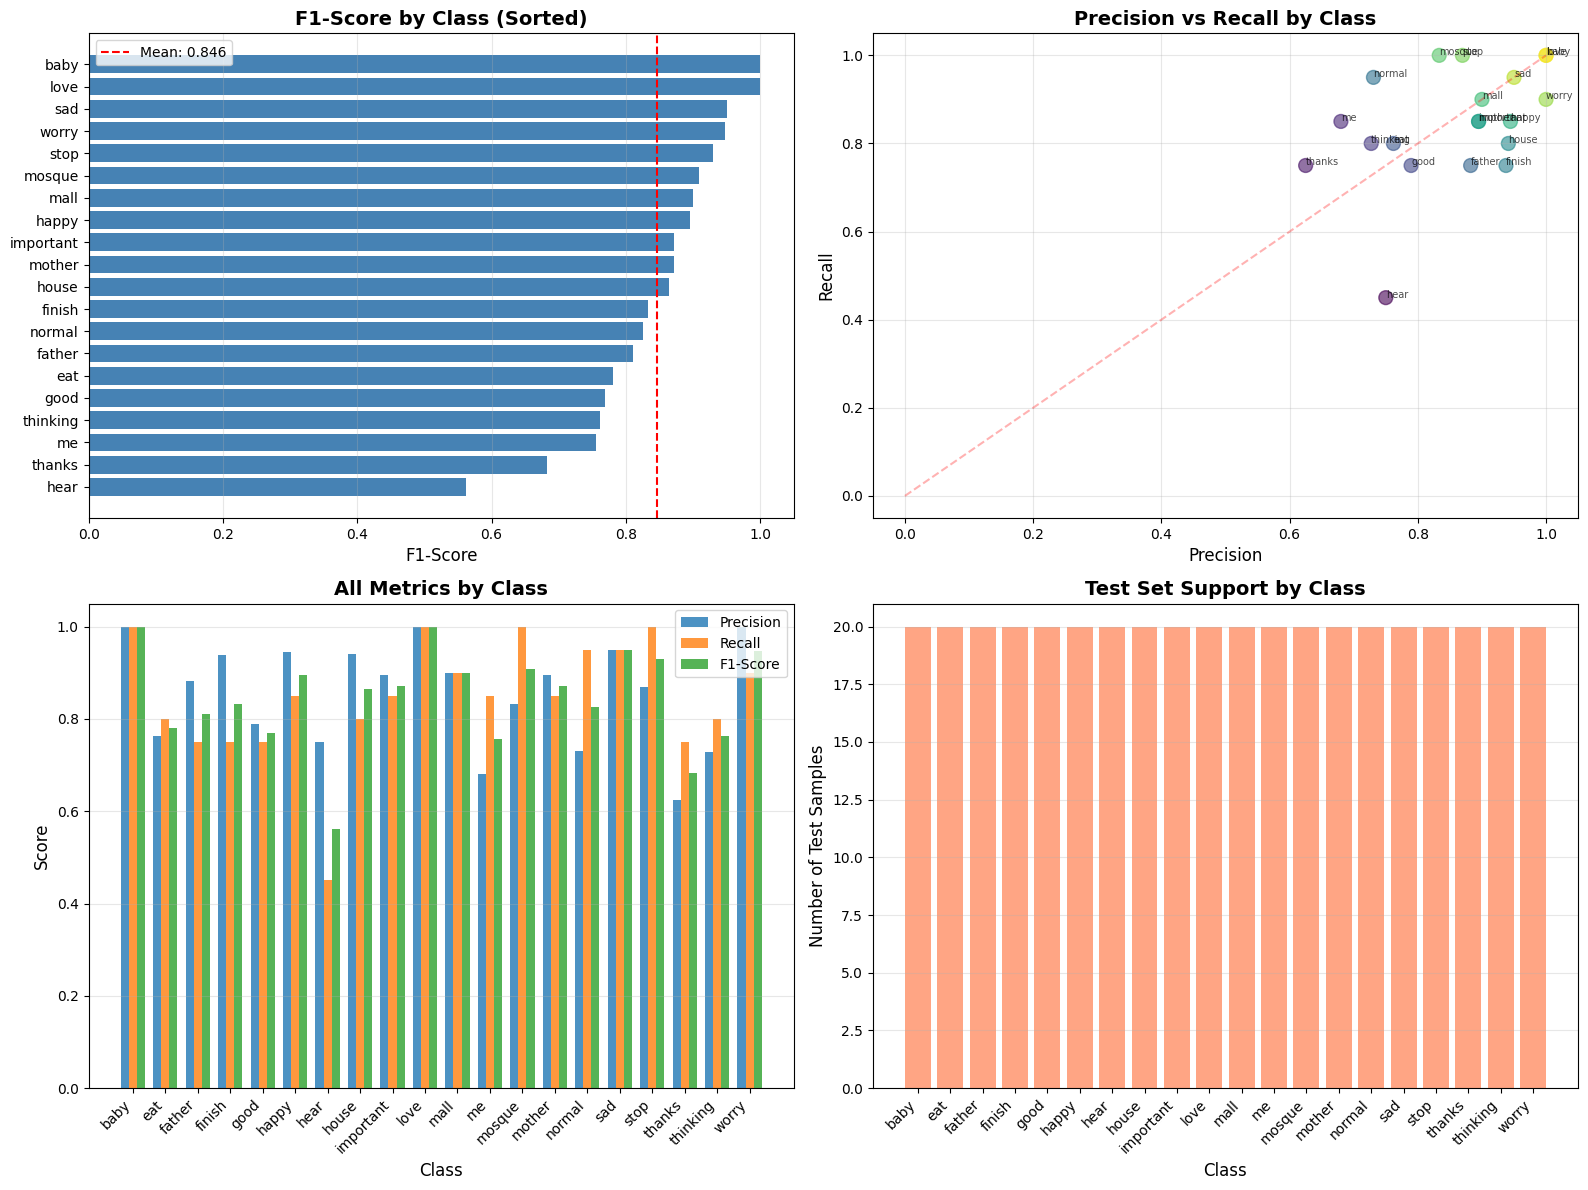

In [22]:
 #============================================================================
# VISUALIZATION 6: Per-Class Performance (After Step 5)
# Add this cell after model evaluation
# ============================================================================

print("\n" + "="*70)
print("VISUALIZATION 6: Per-Class Performance Analysis")
print("="*70)

# Get per-class metrics
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, average=None
)

# Create DataFrame for easier plotting
class_names = classifier.label_encoder.classes_
metrics_df = pd.DataFrame({
    'Class': class_names,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

# Sort by F1-Score
metrics_df = metrics_df.sort_values('F1-Score', ascending=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# F1-Score by class
axes[0, 0].barh(metrics_df['Class'], metrics_df['F1-Score'], color='steelblue')
axes[0, 0].set_xlabel('F1-Score', fontsize=12)
axes[0, 0].set_title('F1-Score by Class (Sorted)', fontsize=14, fontweight='bold')
axes[0, 0].axvline(x=metrics_df['F1-Score'].mean(), color='red', 
                   linestyle='--', label=f'Mean: {metrics_df["F1-Score"].mean():.3f}')
axes[0, 0].legend()
axes[0, 0].grid(axis='x', alpha=0.3)

# Precision vs Recall
axes[0, 1].scatter(metrics_df['Precision'], metrics_df['Recall'], 
                   s=100, alpha=0.6, c=range(len(metrics_df)), cmap='viridis')
axes[0, 1].set_xlabel('Precision', fontsize=12)
axes[0, 1].set_ylabel('Recall', fontsize=12)
axes[0, 1].set_title('Precision vs Recall by Class', fontsize=14, fontweight='bold')
axes[0, 1].plot([0, 1], [0, 1], 'r--', alpha=0.3)
axes[0, 1].grid(alpha=0.3)

# Add class labels
for i, row in metrics_df.iterrows():
    axes[0, 1].annotate(row['Class'], 
                       (row['Precision'], row['Recall']),
                       fontsize=7, alpha=0.7)

# Metrics comparison
x = np.arange(len(class_names))
width = 0.25

axes[1, 0].bar(x - width, metrics_df.set_index('Class').loc[class_names, 'Precision'], 
              width, label='Precision', alpha=0.8)
axes[1, 0].bar(x, metrics_df.set_index('Class').loc[class_names, 'Recall'], 
              width, label='Recall', alpha=0.8)
axes[1, 0].bar(x + width, metrics_df.set_index('Class').loc[class_names, 'F1-Score'], 
              width, label='F1-Score', alpha=0.8)

axes[1, 0].set_xlabel('Class', fontsize=12)
axes[1, 0].set_ylabel('Score', fontsize=12)
axes[1, 0].set_title('All Metrics by Class', fontsize=14, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(class_names, rotation=45, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Support (samples per class in test set)
axes[1, 1].bar(class_names, support, color='coral', alpha=0.7)
axes[1, 1].set_xlabel('Class', fontsize=12)
axes[1, 1].set_ylabel('Number of Test Samples', fontsize=12)
axes[1, 1].set_title('Test Set Support by Class', fontsize=14, fontweight='bold')
axes[1, 1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.OUTPUT_DIR, 'per_class_performance.png'), 
            dpi=200, bbox_inches='tight')
print(f"Per-class performance saved to: {config.OUTPUT_DIR}/per_class_performance.png")
plt.show()

## Step 6: Saving Results
Save the trained model checkpoint and evaluation results.


In [16]:
    # Step 6: Save results
    print("\n" + "="*70)
    print("STEP 6: Saving Results")
    print("-"*70)
    
    # Save model
    model_path = os.path.join(config.OUTPUT_DIR, 'hog_svm_model.pkl')
    classifier.save_model(model_path)
    
    # Visualize results
    visualizer = ResultVisualizer()
    
    cm_path = os.path.join(config.OUTPUT_DIR, 'confusion_matrix.png')
    visualizer.plot_confusion_matrix(
        results['confusion_matrix'],
        classifier.label_encoder.classes_,
        cm_path
    )
    
    metrics_path = os.path.join(config.OUTPUT_DIR, 'metrics_summary.png')
    visualizer.plot_metrics_summary(results, metrics_path)
    
    report_path = os.path.join(config.OUTPUT_DIR, 'results_report.txt')
    visualizer.save_results_report(results, classifier, report_path)
    
    total_time = time.time() - start_time
    
    print("\n" + "="*70)
    print("PIPELINE COMPLETED SUCCESSFULLY!")
    print("="*70)
    print(f"\n⏱️  Total execution time: {total_time:.1f} seconds ({total_time/60:.1f} minutes)")
    print(f"\n📊 Final Accuracy: {results['accuracy']*100:.2f}%")
    print(f"📁 All results saved in: {config.OUTPUT_DIR}/")
    print("="*70)


STEP 6: Saving Results
----------------------------------------------------------------------

Model saved to: output_hog_svm/hog_svm_model.pkl
Confusion matrix saved to: output_hog_svm/confusion_matrix.png
Metrics summary saved to: output_hog_svm/metrics_summary.png
Results report saved to: output_hog_svm/results_report.txt

PIPELINE COMPLETED SUCCESSFULLY!

⏱️  Total execution time: 4994.7 seconds (83.2 minutes)

📊 Final Accuracy: 84.75%
📁 All results saved in: output_hog_svm/
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time= 1.1min
[CV] END ......................C=0.1, gamma=auto, kernel=rbf; total time= 1.0min
[CV] END ...................C=0.1, gamma=auto, kernel=linear; total time=  45.7s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time= 1.0min
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time= 1.0min
[CV] END ...................C=0.1, gamma=0.01, kernel=linear; total time=  46.4s
[CV] END ....................

### Visualization: Training Summary Dashboard
Final overall performance summary.



VISUALIZATION 7: Training Summary Dashboard
Training summary dashboard saved to: output_hog_svm/training_summary_dashboard.png


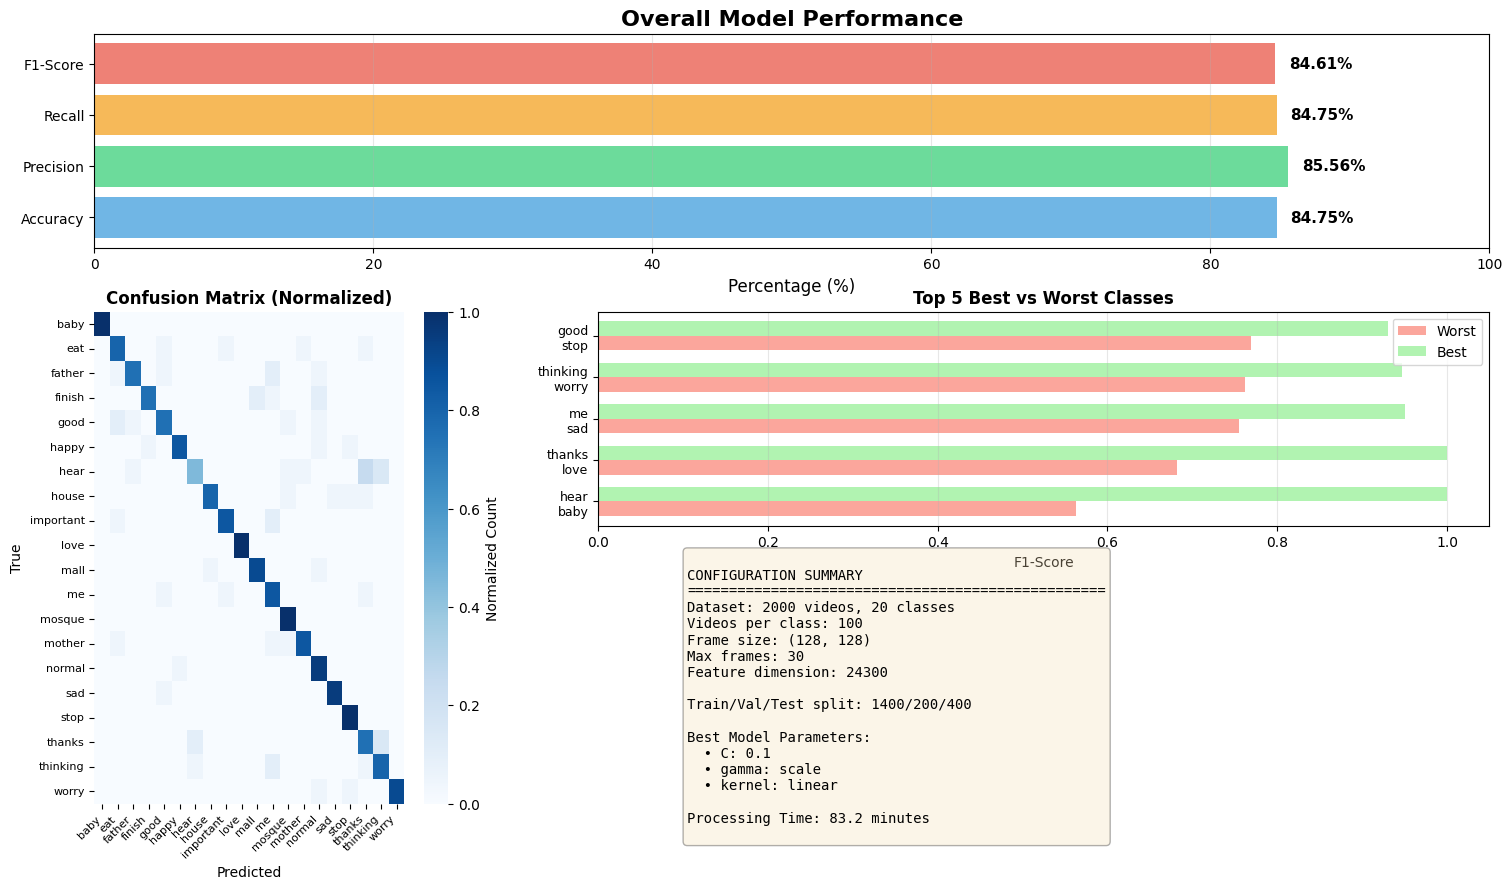


ALL VISUALIZATIONS COMPLETED!


In [23]:
print("\n" + "="*70)
print("VISUALIZATION 7: Training Summary Dashboard")
print("="*70)

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Overall metrics
ax1 = fig.add_subplot(gs[0, :])
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [
    results['accuracy'] * 100,
    results['precision'] * 100,
    results['recall'] * 100,
    results['f1_score'] * 100
]
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
bars = ax1.barh(metrics_names, metrics_values, color=colors, alpha=0.7)
ax1.set_xlabel('Percentage (%)', fontsize=12)
ax1.set_title('Overall Model Performance', fontsize=16, fontweight='bold')
ax1.set_xlim(0, 100)
for i, (bar, val) in enumerate(zip(bars, metrics_values)):
    ax1.text(val + 1, i, f'{val:.2f}%', va='center', fontsize=11, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Confusion matrix (compact)
ax2 = fig.add_subplot(gs[1:, 0])
cm_normalized = results['confusion_matrix'].astype('float') / results['confusion_matrix'].sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=False, fmt='.2f', cmap='Blues',
            xticklabels=classifier.label_encoder.classes_,
            yticklabels=classifier.label_encoder.classes_,
            cbar_kws={'label': 'Normalized Count'}, ax=ax2)
ax2.set_xlabel('Predicted', fontsize=10)
ax2.set_ylabel('True', fontsize=10)
ax2.set_title('Confusion Matrix (Normalized)', fontsize=12, fontweight='bold')
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.setp(ax2.get_yticklabels(), rotation=0, fontsize=8)

# Best and worst performing classes
ax3 = fig.add_subplot(gs[1, 1:])
sorted_metrics = metrics_df.sort_values('F1-Score')
n_show = 5
worst_classes = sorted_metrics.head(n_show)
best_classes = sorted_metrics.tail(n_show)

x = np.arange(n_show)
width = 0.35

ax3.barh(x - width/2, worst_classes['F1-Score'].values, width, 
        label='Worst', color='salmon', alpha=0.7)
ax3.barh(x + width/2, best_classes['F1-Score'].values[::-1], width, 
        label='Best', color='lightgreen', alpha=0.7)

ax3.set_yticks(x)
ax3.set_yticklabels([f"{w}\n{b}" for w, b in 
                     zip(worst_classes['Class'].values, 
                         best_classes['Class'].values[::-1])], 
                    fontsize=9)
ax3.set_xlabel('F1-Score', fontsize=10)
ax3.set_title(f'Top {n_show} Best vs Worst Classes', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(axis='x', alpha=0.3)

# Configuration summary
ax4 = fig.add_subplot(gs[2, 1:])
ax4.axis('off')
config_text = f"""
CONFIGURATION SUMMARY
{'='*50}
Dataset: {len(all_labels)} videos, {len(np.unique(all_labels))} classes
Videos per class: {config.MAX_VIDEOS_PER_CLASS if config.MAX_VIDEOS_PER_CLASS else 'ALL'}
Frame size: {config.FRAME_SIZE}
Max frames: {config.MAX_FRAMES}
Feature dimension: {X.shape[1]}

Train/Val/Test split: {len(X_train)}/{len(X_val)}/{len(X_test)}

Best Model Parameters:
{chr(10).join([f"  • {k}: {v}" for k, v in classifier.best_params.items()])}

Processing Time: {total_time/60:.1f} minutes
"""
ax4.text(0.1, 0.5, config_text, fontsize=10, family='monospace',
        verticalalignment='center', bbox=dict(boxstyle='round', 
        facecolor='wheat', alpha=0.3))

plt.savefig(os.path.join(config.OUTPUT_DIR, 'training_summary_dashboard.png'), 
            dpi=200, bbox_inches='tight')
print(f"Training summary dashboard saved to: {config.OUTPUT_DIR}/training_summary_dashboard.png")
plt.show()

print("\n" + "="*70)
print("ALL VISUALIZATIONS COMPLETED!")
print("="*70)

## Step 1: Loading Dataset
Load the ASL-20 dataset from the directory structure into memory.


In [5]:
"""
ASL-20 Words Sign Language Recognition using CNN + LSTM
Dataset: ASL-20-Words-Dataset-V1
Author: Sign Language Recognition Tutorial - Deep Learning Group

QUICK START GUIDE:
==================
1. Update DATASET_PATH to match your HOG+SVM setup
2. Adjust MAX_VIDEOS_PER_CLASS (use same value as HOG+SVM for fair comparison)
3. Configure EPOCHS and BATCH_SIZE based on your resources
4. Run the script!

EXPECTED TRAINING TIMES (approximate on GPU):
- 50 videos/class:   20-30 minutes
- 100 videos/class:  40-60 minutes
- 200 videos/class:  1.5-2 hours
- ALL videos:        3-5 hours
"""

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import pickle
import random
import warnings
import time
warnings.filterwarnings('ignore')

# Deep Learning imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (ModelCheckpoint, EarlyStopping, 
                                       ReduceLROnPlateau, CSVLogger)
from tensorflow.keras.utils import to_categorical

# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_recall_fscore_support,
                             top_k_accuracy_score)

# Mediapipe for hand detection (optional)
try:
    import mediapipe as mp
    MEDIAPIPE_AVAILABLE = True
except (ImportError, AttributeError):
    MEDIAPIPE_AVAILABLE = False
    print("WARNING: MediaPipe not available. Hand detection will be disabled.")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# ============================================================================
# CONFIGURATION
# ============================================================================

class Config:
    """Configuration parameters for CNN+LSTM model"""
    # Paths - UPDATE THIS TO YOUR ACTUAL PATH
    DATASET_PATH = "/kaggle/input/asl-20-words-dataset-v1/Full Data"
    OUTPUT_DIR = "output_cnn_lstm"
    
    # Dataset sampling - MATCH YOUR HOG+SVM SETTINGS
    MAX_VIDEOS_PER_CLASS = 100  # Match with HOG+SVM for fair comparison
    SHUFFLE_VIDEOS = True
    
    # Video processing
    MAX_FRAMES = 30  # Sequence length for LSTM
    FRAME_SIZE = (64, 64)  # Smaller than HOG for memory efficiency
    
    # Model architecture
    CNN_FILTERS = [32, 64, 128]  # Convolutional filters per layer
    LSTM_UNITS = 128  # LSTM hidden units
    DENSE_UNITS = 256  # Fully connected layer units
    DROPOUT_RATE = 0.5
    
    # Training parameters
    BATCH_SIZE = 16  # Adjust based on GPU memory
    EPOCHS = 50
    LEARNING_RATE = 0.001
    
    # Data split
    TEST_SIZE = 0.2
    VALIDATION_SIZE = 0.1
    RANDOM_STATE = 42
    
    # Hand detection
    USE_HAND_DETECTION = False  # Set to True if MediaPipe is installed
    HAND_DETECTION_CONFIDENCE = 0.5
    
    # Data augmentation
    USE_AUGMENTATION = True
    AUGMENTATION_PROB = 0.3

# Create output directory
os.makedirs(Config.OUTPUT_DIR, exist_ok=True)

print("GPU Available:", tf.config.list_physical_devices('GPU'))
print("TensorFlow version:", tf.__version__)

# ============================================================================
# HAND DETECTION MODULE
# ============================================================================

class HandDetector:
    """Detect and crop hand regions using MediaPipe"""
    
    def __init__(self, confidence=0.5):
        if not MEDIAPIPE_AVAILABLE:
            raise ImportError("MediaPipe is not available. Please install it with: pip install mediapipe")
        
        self.mp_hands = mp.solutions.hands
        self.hands = self.mp_hands.Hands(
            static_image_mode=True,
            max_num_hands=2,
            min_detection_confidence=confidence
        )
    
    def detect_hand_region(self, frame):
        """Detect hand region and return cropped bounding box"""
        h, w, _ = frame.shape
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = self.hands.process(rgb_frame)
        
        if results.multi_hand_landmarks:
            all_x, all_y = [], []
            for hand_landmarks in results.multi_hand_landmarks:
                for landmark in hand_landmarks.landmark:
                    all_x.append(int(landmark.x * w))
                    all_y.append(int(landmark.y * h))
            
            padding = 30
            x_min = max(0, min(all_x) - padding)
            x_max = min(w, max(all_x) + padding)
            y_min = max(0, min(all_y) - padding)
            y_max = min(h, max(all_y) + padding)
            
            cropped = frame[y_min:y_max, x_min:x_max]
            if cropped.size > 0:
                return cropped
        
        return frame
    
    def close(self):
        self.hands.close()

# ============================================================================
# DATA AUGMENTATION
# ============================================================================

class VideoAugmentor:
    """Apply data augmentation to video frames"""
    
    def __init__(self, config):
        self.config = config
        self.prob = config.AUGMENTATION_PROB
    
    def random_brightness(self, frame):
        """Randomly adjust brightness"""
        if random.random() < self.prob:
            factor = random.uniform(0.7, 1.3)
            frame = np.clip(frame * factor, 0, 1)
        return frame
    
    def random_rotation(self, frame):
        """Randomly rotate frame"""
        if random.random() < self.prob:
            angle = random.uniform(-15, 15)
            h, w = frame.shape[:2]
            M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
            frame = cv2.warpAffine(frame, M, (w, h))
        return frame
    
    def random_flip(self, frame):
        """Randomly flip frame horizontally"""
        if random.random() < self.prob:
            frame = cv2.flip(frame, 1)
        return frame
    
    def augment_frame(self, frame):
        """Apply random augmentations to a single frame"""
        frame = self.random_brightness(frame)
        frame = self.random_rotation(frame)
        frame = self.random_flip(frame)
        return frame

# ============================================================================
# DATA LOADING AND PREPROCESSING
# ============================================================================

class VideoProcessor:
    """Process videos and extract frames for deep learning"""
    
    def __init__(self, config):
        self.config = config
        
        # Check if hand detection is requested but not available
        if config.USE_HAND_DETECTION and not MEDIAPIPE_AVAILABLE:
            print("WARNING: Hand detection requested but MediaPipe not available.")
            print("         Continuing WITHOUT hand detection.")
            self.hand_detector = None
        elif config.USE_HAND_DETECTION:
            self.hand_detector = HandDetector(config.HAND_DETECTION_CONFIDENCE)
        else:
            self.hand_detector = None
            
        self.augmentor = VideoAugmentor(config) if config.USE_AUGMENTATION else None
    
    def extract_frames(self, video_path, max_frames=None, augment=False):
        """Extract and preprocess frames from video"""
        if max_frames is None:
            max_frames = self.config.MAX_FRAMES
        
        cap = cv2.VideoCapture(video_path)
        frames = []
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        if frame_count > max_frames:
            interval = frame_count // max_frames
        else:
            interval = 1
        
        frame_idx = 0
        while len(frames) < max_frames:
            ret, frame = cap.read()
            if not ret:
                break
            
            if frame_idx % interval == 0:
                # Hand detection
                if self.hand_detector:
                    frame = self.hand_detector.detect_hand_region(frame)
                
                # Resize
                frame = cv2.resize(frame, self.config.FRAME_SIZE)
                
                # Convert to RGB and normalize
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = frame.astype(np.float32) / 255.0
                
                # Augment if training
                if augment and self.augmentor:
                    frame = self.augmentor.augment_frame(frame)
                
                frames.append(frame)
            
            frame_idx += 1
        
        cap.release()
        
        # Pad with zeros if not enough frames
        while len(frames) < max_frames:
            frames.append(np.zeros((*self.config.FRAME_SIZE, 3)))
        
        return np.array(frames[:max_frames])
    
    def close(self):
        if self.hand_detector:
            self.hand_detector.close()

class DataLoader:
    """Load and organize dataset for deep learning"""
    
    def __init__(self, config):
        self.config = config
        self.processor = VideoProcessor(config)
    
    def load_dataset(self):
        """Load videos from dataset"""
        dataset_path = Path(self.config.DATASET_PATH)
        
        if not dataset_path.exists():
            raise FileNotFoundError(f"Dataset path not found: {dataset_path}")
        
        video_paths = []
        labels = []
        
        class_folders = sorted([f for f in dataset_path.iterdir() if f.is_dir()])
        
        print(f"Found {len(class_folders)} classes")
        
        if self.config.MAX_VIDEOS_PER_CLASS:
            print(f"Sampling mode: MAX {self.config.MAX_VIDEOS_PER_CLASS} videos per class")
        else:
            print("Loading ALL videos from each class")
        
        print("-" * 70)
        
        for class_folder in class_folders:
            class_name = class_folder.name
            video_files = list(class_folder.glob("*.mp4"))
            
            total_available = len(video_files)
            
            if self.config.MAX_VIDEOS_PER_CLASS and total_available > self.config.MAX_VIDEOS_PER_CLASS:
                if self.config.SHUFFLE_VIDEOS:
                    random.seed(self.config.RANDOM_STATE)
                    video_files = random.sample(video_files, self.config.MAX_VIDEOS_PER_CLASS)
                else:
                    video_files = video_files[:self.config.MAX_VIDEOS_PER_CLASS]
                
                print(f"Class '{class_name:15s}': {len(video_files):3d} videos (sampled from {total_available})")
            else:
                print(f"Class '{class_name:15s}': {len(video_files):3d} videos (all available)")
            
            for video_file in video_files:
                video_paths.append(str(video_file))
                labels.append(class_name)
        
        print("-" * 70)
        print(f"Total videos loaded: {len(video_paths)}")
        print(f"Total classes: {len(set(labels))}")
        
        return video_paths, labels
    
    def process_videos(self, video_paths, labels, augment=False):
        """Process all videos"""
        all_frames = []
        valid_labels = []
        
        desc = "Processing videos (with augmentation)" if augment else "Processing videos"
        print(f"\n{desc}...")
        
        for video_path, label in tqdm(zip(video_paths, labels), total=len(video_paths)):
            try:
                frames = self.processor.extract_frames(video_path, augment=augment)
                all_frames.append(frames)
                valid_labels.append(label)
            except Exception as e:
                print(f"Error processing {video_path}: {e}")
                continue
        
        self.processor.close()
        return np.array(all_frames), np.array(valid_labels)

# ============================================================================
# CNN + LSTM MODEL ARCHITECTURE
# ============================================================================

class CNNLSTMModel:
    """CNN + LSTM model for video-based sign language recognition"""
    
    def __init__(self, config, num_classes):
        self.config = config
        self.num_classes = num_classes
        self.model = None
        self.history = None
        self.label_encoder = LabelEncoder()
    
    def build_model(self):
        """Build CNN+LSTM architecture"""
        print("\nBuilding CNN+LSTM Model...")
        print("-" * 70)
        
        # Input: (batch, frames, height, width, channels)
        input_shape = (self.config.MAX_FRAMES, *self.config.FRAME_SIZE, 3)
        
        # TimeDistributed CNN for spatial feature extraction
        inputs = layers.Input(shape=input_shape)
        
        # CNN layers (applied to each frame independently)
        x = layers.TimeDistributed(
            layers.Conv2D(self.config.CNN_FILTERS[0], (3, 3), activation='relu', padding='same')
        )(inputs)
        x = layers.TimeDistributed(layers.BatchNormalization())(x)
        x = layers.TimeDistributed(layers.MaxPooling2D((2, 2)))(x)
        x = layers.TimeDistributed(layers.Dropout(0.25))(x)
        
        x = layers.TimeDistributed(
            layers.Conv2D(self.config.CNN_FILTERS[1], (3, 3), activation='relu', padding='same')
        )(x)
        x = layers.TimeDistributed(layers.BatchNormalization())(x)
        x = layers.TimeDistributed(layers.MaxPooling2D((2, 2)))(x)
        x = layers.TimeDistributed(layers.Dropout(0.25))(x)
        
        x = layers.TimeDistributed(
            layers.Conv2D(self.config.CNN_FILTERS[2], (3, 3), activation='relu', padding='same')
        )(x)
        x = layers.TimeDistributed(layers.BatchNormalization())(x)
        x = layers.TimeDistributed(layers.MaxPooling2D((2, 2)))(x)
        x = layers.TimeDistributed(layers.Dropout(0.25))(x)
        
        # Flatten CNN output for LSTM
        x = layers.TimeDistributed(layers.Flatten())(x)
        
        # LSTM layers for temporal modeling
        x = layers.LSTM(self.config.LSTM_UNITS, return_sequences=True)(x)
        x = layers.Dropout(self.config.DROPOUT_RATE)(x)
        
        x = layers.LSTM(self.config.LSTM_UNITS // 2, return_sequences=False)(x)
        x = layers.Dropout(self.config.DROPOUT_RATE)(x)
        
        # Dense layers
        x = layers.Dense(self.config.DENSE_UNITS, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(self.config.DROPOUT_RATE)(x)
        
        # Output layer
        outputs = layers.Dense(self.num_classes, activation='softmax')(x)
        
        # Create model
        self.model = models.Model(inputs=inputs, outputs=outputs)
        
        # Compile
        optimizer = keras.optimizers.Adam(learning_rate=self.config.LEARNING_RATE)
        self.model.compile(
            optimizer=optimizer,
            loss='categorical_crossentropy',
            metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=3, name='top_3_accuracy')]
        )
        
        print(self.model.summary())
        print("-" * 70)
        
        return self.model
    
    def prepare_data(self, X, y):
        """Encode labels and split data"""
        # Encode labels
        y_encoded = self.label_encoder.fit_transform(y)
        y_categorical = to_categorical(y_encoded, num_classes=self.num_classes)
        
        # Split data
        X_temp, X_test, y_temp, y_test = train_test_split(
            X, y_categorical,
            test_size=self.config.TEST_SIZE,
            random_state=self.config.RANDOM_STATE,
            stratify=y_encoded
        )
        
        y_temp_labels = np.argmax(y_temp, axis=1)
        X_train, X_val, y_train, y_val = train_test_split(
            X_temp, y_temp,
            test_size=self.config.VALIDATION_SIZE / (1 - self.config.TEST_SIZE),
            random_state=self.config.RANDOM_STATE,
            stratify=y_temp_labels
        )
        
        print(f"\nData split:")
        print(f"Train: {X_train.shape[0]} samples")
        print(f"Validation: {X_val.shape[0]} samples")
        print(f"Test: {X_test.shape[0]} samples")
        print(f"Input shape: {X_train.shape[1:]}")
        
        return (X_train, y_train), (X_val, y_val), (X_test, y_test)
    
    def train(self, X_train, y_train, X_val, y_val):
        """Train the model"""
        print("\nTraining CNN+LSTM Model...")
        print("-" * 70)
        
        # Callbacks
        callbacks = [
            ModelCheckpoint(
                os.path.join(self.config.OUTPUT_DIR, 'best_model.h5'),
                monitor='val_accuracy',
                save_best_only=True,
                mode='max',
                verbose=1
            ),
            EarlyStopping(
                monitor='val_loss',
                patience=10,
                restore_best_weights=True,
                verbose=1
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=5,
                min_lr=1e-7,
                verbose=1
            ),
            CSVLogger(
                os.path.join(self.config.OUTPUT_DIR, 'training_log.csv')
            )
        ]
        
        # Train
        self.history = self.model.fit(
            X_train, y_train,
            batch_size=self.config.BATCH_SIZE,
            epochs=self.config.EPOCHS,
            validation_data=(X_val, y_val),
            callbacks=callbacks,
            verbose=1
        )
        
        return self.history
    
    def evaluate(self, X_test, y_test):
        """Comprehensive evaluation"""
        print("\n" + "="*70)
        print("EVALUATION RESULTS - CNN+LSTM")
        print("="*70)
        
        # Predictions
        y_pred_proba = self.model.predict(X_test, verbose=0)
        y_pred = np.argmax(y_pred_proba, axis=1)
        y_true = np.argmax(y_test, axis=1)
        
        # Accuracy metrics
        accuracy = accuracy_score(y_true, y_pred)
        print(f"\n1. Classification Accuracy: {accuracy*100:.2f}%")
        
        # Top-k accuracy
        top_3_acc = top_k_accuracy_score(y_true, y_pred_proba, k=3)
        top_5_acc = top_k_accuracy_score(y_true, y_pred_proba, k=5)
        print(f"2. Top-3 Accuracy: {top_3_acc*100:.2f}%")
        print(f"3. Top-5 Accuracy: {top_5_acc*100:.2f}%")
        
        # Precision, Recall, F1
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average='weighted'
        )
        print(f"\n4. Weighted Precision: {precision*100:.2f}%")
        print(f"5. Weighted Recall: {recall*100:.2f}%")
        print(f"6. Weighted F1-Score: {f1*100:.2f}%")
        
        # Per-class metrics
        print("\n7. Per-Class Performance:")
        print("-" * 70)
        class_report = classification_report(
            y_true, y_pred,
            target_names=self.label_encoder.classes_,
            digits=3
        )
        print(class_report)
        
        # Confusion matrix
        cm = confusion_matrix(y_true, y_pred)
        
        return {
            'accuracy': accuracy,
            'top_3_accuracy': top_3_acc,
            'top_5_accuracy': top_5_acc,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'confusion_matrix': cm,
            'y_pred': y_pred,
            'y_true': y_true,
            'classification_report': class_report
        }
    
    def save_model(self, filepath):
        """Save model and label encoder"""
        self.model.save(filepath)
        
        encoder_path = filepath.replace('.h5', '_encoder.pkl')
        with open(encoder_path, 'wb') as f:
            pickle.dump(self.label_encoder, f)
        
        print(f"\nModel saved to: {filepath}")
        print(f"Label encoder saved to: {encoder_path}")
    
    def load_model(self, filepath):
        """Load model and label encoder"""
        self.model = keras.models.load_model(filepath)
        
        encoder_path = filepath.replace('.h5', '_encoder.pkl')
        with open(encoder_path, 'rb') as f:
            self.label_encoder = pickle.load(f)
        
        print(f"\nModel loaded from: {filepath}")

# ============================================================================
# VISUALIZATION
# ============================================================================

class ResultVisualizer:
    """Visualize training and evaluation results"""
    
    @staticmethod
    def plot_training_history(history, output_path):
        """Plot training and validation metrics"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Accuracy
        axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
        axes[0, 0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
        axes[0, 0].set_title('Model Accuracy', fontsize=12, fontweight='bold')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Accuracy')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # Loss
        axes[0, 1].plot(history.history['loss'], label='Train Loss', linewidth=2)
        axes[0, 1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
        axes[0, 1].set_title('Model Loss', fontsize=12, fontweight='bold')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Loss')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        # Top-3 Accuracy
        axes[1, 0].plot(history.history['top_3_accuracy'], label='Train Top-3', linewidth=2)
        axes[1, 0].plot(history.history['val_top_3_accuracy'], label='Val Top-3', linewidth=2)
        axes[1, 0].set_title('Top-3 Accuracy', fontsize=12, fontweight='bold')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Top-3 Accuracy')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        # Learning rate (if available)
        if 'lr' in history.history:
            axes[1, 1].plot(history.history['lr'], linewidth=2, color='orange')
            axes[1, 1].set_title('Learning Rate', fontsize=12, fontweight='bold')
            axes[1, 1].set_xlabel('Epoch')
            axes[1, 1].set_ylabel('Learning Rate')
            axes[1, 1].set_yscale('log')
            axes[1, 1].grid(True, alpha=0.3)
        else:
            axes[1, 1].text(0.5, 0.5, 'Learning Rate\nNot Logged', 
                           ha='center', va='center', fontsize=12)
            axes[1, 1].axis('off')
        
        plt.tight_layout()
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"Training history saved to: {output_path}")
        plt.close()
    
    @staticmethod
    def plot_confusion_matrix(cm, class_names, output_path):
        """Plot confusion matrix"""
        plt.figure(figsize=(14, 12))
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Count'}
        )
        plt.xlabel('Predicted Label', fontsize=12)
        plt.ylabel('True Label', fontsize=12)
        plt.title('Confusion Matrix - CNN+LSTM Sign Language Recognition', fontsize=14)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"Confusion matrix saved to: {output_path}")
        plt.close()
    
    @staticmethod
    def plot_metrics_comparison(results, output_path):
        """Plot comparison of metrics"""
        metrics = {
            'Accuracy': results['accuracy'] * 100,
            'Top-3 Acc': results['top_3_accuracy'] * 100,
            'Top-5 Acc': results['top_5_accuracy'] * 100,
            'Precision': results['precision'] * 100,
            'Recall': results['recall'] * 100,
            'F1-Score': results['f1_score'] * 100
        }
        
        plt.figure(figsize=(12, 6))
        bars = plt.bar(metrics.keys(), metrics.values(), 
                      color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6', '#1abc9c'])
        plt.ylabel('Percentage (%)', fontsize=12)
        plt.title('Performance Metrics Summary - CNN+LSTM', fontsize=14, fontweight='bold')
        plt.ylim(0, 100)
        plt.xticks(rotation=30, ha='right')
        
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}%',
                    ha='center', va='bottom', fontsize=10)
        
        plt.tight_layout()
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"Metrics comparison saved to: {output_path}")
        plt.close()
    
    @staticmethod
    def save_results_report(results, config, output_path):
        """Save detailed results report"""
        with open(output_path, 'w') as f:
            f.write("="*70 + "\n")
            f.write("SIGN LANGUAGE RECOGNITION - CNN+LSTM MODEL\n")
            f.write("="*70 + "\n\n")
            
            f.write("CONFIGURATION:\n")
            f.write(f"- Frame Size: {config.FRAME_SIZE}\n")
            f.write(f"- Max Frames per Video: {config.MAX_FRAMES}\n")
            f.write(f"- CNN Filters: {config.CNN_FILTERS}\n")
            f.write(f"- LSTM Units: {config.LSTM_UNITS}\n")
            f.write(f"- Dense Units: {config.DENSE_UNITS}\n")
            f.write(f"- Dropout Rate: {config.DROPOUT_RATE}\n")
            f.write(f"- Batch Size: {config.BATCH_SIZE}\n")
            f.write(f"- Learning Rate: {config.LEARNING_RATE}\n")
            f.write(f"- Hand Detection: {config.USE_HAND_DETECTION}\n")
            f.write(f"- Data Augmentation: {config.USE_AUGMENTATION}\n\n")
            
            f.write("PERFORMANCE METRICS:\n")
            f.write(f"- Classification Accuracy: {results['accuracy']*100:.2f}%\n")
            f.write(f"- Top-3 Accuracy: {results['top_3_accuracy']*100:.2f}%\n")
            f.write(f"- Top-5 Accuracy: {results['top_5_accuracy']*100:.2f}%\n")
            f.write(f"- Weighted Precision: {results['precision']*100:.2f}%\n")
            f.write(f"- Weighted Recall: {results['recall']*100:.2f}%\n")
            f.write(f"- Weighted F1-Score: {results['f1_score']*100:.2f}%\n\n")
            
            f.write("DETAILED CLASSIFICATION REPORT:\n")
            f.write("-"*70 + "\n")
            f.write(results['classification_report'])
            f.write("\n")
        
        print(f"Results report saved to: {output_path}")

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """Main execution pipeline"""
    
    config = Config()
    
    print("="*70)
    print("CNN+LSTM SIGN LANGUAGE RECOGNITION PIPELINE")
    print("="*70)
    
    total_start = time.time()
    
    # STEP 1: Load Dataset
    print("\nSTEP 1: Loading Dataset")
    print("-"*70)
    step1_start = time.time()
    loader = DataLoader(config)
    video_paths, labels = loader.load_dataset()
    step1_time = time.time() - step1_start
    print(f"\n⏱️  Step 1 completed in {step1_time:.1f} seconds")
    
    # STEP 2: Process Videos
    print("\n" + "="*70)
    print("STEP 2: Processing Videos")
    print("-"*70)
    step2_start = time.time()
    all_frames, all_labels = loader.process_videos(video_paths, labels, augment=False)
    step2_time = time.time() - step2_start
    
    print(f"\nProcessed: {len(all_frames)} videos")
    print(f"Frame shape per video: {all_frames[0].shape}")
    print(f"⏱️  Step 2 completed in {step2_time:.1f} seconds ({step2_time/60:.1f} minutes)")
    
    # STEP 3: Prepare Data and Build Model
    print("\n" + "="*70)
    print("STEP 3: Preparing Data and Building Model")
    print("-"*70)
    
    num_classes = len(np.unique(all_labels))
    print(f"Number of classes: {num_classes}")
    
    model = CNNLSTMModel(config, num_classes)
    model.build_model()
    
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = model.prepare_data(all_frames, all_labels)
    
    # STEP 4: Train Model
    print("\n" + "="*70)
    print("STEP 4: Training Model")
    print("-"*70)
    step4_start = time.time()
    
    history = model.train(X_train, y_train, X_val, y_val)
    
    step4_time = time.time() - step4_start
    print(f"\n⏱️  Step 4 completed in {step4_time:.1f} seconds ({step4_time/60:.1f} minutes)")
    
    # STEP 5: Evaluate Model
    print("\n" + "="*70)
    print("STEP 5: Model Evaluation")
    print("-"*70)
    step5_start = time.time()
    
    results = model.evaluate(X_test, y_test)
    
    step5_time = time.time() - step5_start
    print(f"\n⏱️  Step 5 completed in {step5_time:.1f} seconds")
    
    # STEP 6: Visualization and Reporting
    print("\n" + "="*70)
    print("STEP 6: Generating Visualizations and Reports")
    print("-"*70)
    
    visualizer = ResultVisualizer()
    
    # Plot training history
    visualizer.plot_training_history(
        history,
        os.path.join(config.OUTPUT_DIR, 'training_history.png')
    )
    
    # Plot confusion matrix
    visualizer.plot_confusion_matrix(
        results['confusion_matrix'],
        model.label_encoder.classes_,
        os.path.join(config.OUTPUT_DIR, 'confusion_matrix.png')
    )
    
    # Plot metrics comparison
    visualizer.plot_metrics_comparison(
        results,
        os.path.join(config.OUTPUT_DIR, 'metrics_comparison.png')
    )
    
    # Save results report
    visualizer.save_results_report(
        results,
        config,
        os.path.join(config.OUTPUT_DIR, 'results_report.txt')
    )
    
    # Save model
    model.save_model(os.path.join(config.OUTPUT_DIR, 'final_model.h5'))
    
    # Total time
    total_time = time.time() - total_start
    
    print("\n" + "="*70)
    print("PIPELINE COMPLETED SUCCESSFULLY!")
    print("="*70)
    print(f"\n⏱️  Total execution time: {total_time:.1f} seconds ({total_time/60:.1f} minutes)")
    print(f"\nAll outputs saved to: {config.OUTPUT_DIR}")
    print("\nKey Results:")
    print(f"  - Test Accuracy: {results['accuracy']*100:.2f}%")
    print(f"  - Top-3 Accuracy: {results['top_3_accuracy']*100:.2f}%")
    print(f"  - F1-Score: {results['f1_score']*100:.2f}%")

if __name__ == "__main__":
    main()

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
TensorFlow version: 2.18.0
CNN+LSTM SIGN LANGUAGE RECOGNITION PIPELINE

STEP 1: Loading Dataset
----------------------------------------------------------------------
Found 20 classes
Sampling mode: MAX 100 videos per class
----------------------------------------------------------------------
Class 'baby           ': 100 videos (sampled from 430)
Class 'eat            ': 100 videos (sampled from 440)
Class 'father         ': 100 videos (sampled from 452)
Class 'finish         ': 100 videos (sampled from 440)
Class 'good           ': 100 videos (sampled from 436)
Class 'happy          ': 100 videos (sampled from 445)
Class 'hear           ': 100 videos (sampled from 433)
Class 'house          ': 100 videos (sampled from 421)
Class 'important      ': 100 videos (sampled from 446)
Class 'love           ': 100 videos (sampled from 435)
Class '

  8%|▊         | 159/2000 [01:05<09:38,  3.18it/s][h264 @ 0x484f4040] Invalid NAL unit size (9616 > 8211).
[h264 @ 0x484f4040] Error splitting the input into NAL units.
 13%|█▎        | 251/2000 [01:38<11:25,  2.55it/s][h264 @ 0x4d877fc0] Invalid NAL unit size (15412 > 6576).
[h264 @ 0x4d877fc0] Error splitting the input into NAL units.
 14%|█▍        | 282/2000 [01:48<09:01,  3.17it/s][h264 @ 0x484c2d00] Invalid NAL unit size (12498 > 12021).
[h264 @ 0x484c2d00] Error splitting the input into NAL units.
 17%|█▋        | 337/2000 [02:10<07:36,  3.64it/s][h264 @ 0x4baf1940] Invalid NAL unit size (14807 > 12329).
[h264 @ 0x4baf1940] Error splitting the input into NAL units.
 18%|█▊        | 357/2000 [02:19<11:28,  2.39it/s][h264 @ 0x48496340] Invalid NAL unit size (13614 > 13085).
[h264 @ 0x48496340] Error splitting the input into NAL units.
 20%|█▉        | 391/2000 [02:29<08:56,  3.00it/s][h264 @ 0x4b967f80] Invalid NAL unit size (12676 > 9233).
[h264 @ 0x4b967f80] Error splitting the 


Processed: 2000 videos
Frame shape per video: (30, 64, 64, 3)
⏱️  Step 2 completed in 759.8 seconds (12.7 minutes)

STEP 3: Preparing Data and Building Model
----------------------------------------------------------------------
Number of classes: 20

Building CNN+LSTM Model...
----------------------------------------------------------------------


I0000 00:00:1765913641.868452      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1765913641.869074      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

...

88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.0487 - loss: 4.1780 - top_3_accuracy: 0.1424
Epoch 1: val_accuracy improved from -inf to 0.05000, saving model to output_cnn_lstm/best_model.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 87s 573ms/step - accuracy: 0.0486 - loss: 4.1767 - top_3_accuracy: 0.1423 - val_accuracy: 0.0500 - val_loss: 3.0074 - val_top_3_accuracy: 0.1450 - learning_rate: 0.0010
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - accuracy: 0.0603 - loss: 3.8050 - top_3_accuracy: 0.1435
Epoch 2: val_accuracy did not improve from 0.05000
88/88 ━━━━━━━━━━━━━━━━━━━━ 45s 511ms/step - accuracy: 0.0601 - loss: 3.8040 - top_3_accuracy: 0.1435 - val_accuracy: 0.0500 - val_loss: 2.9967 - val_top_3_accuracy: 0.1750 - learning_rate: 0.0010
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.0515 - loss: 3.6012 - top_3_accuracy: 0.1475
Epoch 3: val_accuracy did not improve from 0.05000
88/88 ━━━━━━━━━━━━━━━━━━━━ 45s 514ms/step - accuracy: 0.0516 - loss: 3.6005 - top_3_accuracy: 0.1475 - val_accuracy: 0.0500 - val_loss: 3.0052 - val_top_3_accuracy: 0.1600 - learning_rate: 0.0010
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.0539 - loss: 3.5106 - 

88/88 ━━━━━━━━━━━━━━━━━━━━ 46s 517ms/step - accuracy: 0.0539 - loss: 3.5109 - top_3_accuracy: 0.1643 - val_accuracy: 0.0550 - val_loss: 3.0172 - val_top_3_accuracy: 0.1600 - learning_rate: 0.0010
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.0365 - loss: 3.4383 - top_3_accuracy: 0.1346
Epoch 5: val_accuracy did not improve from 0.05500
88/88 ━━━━━━━━━━━━━━━━━━━━ 45s 515ms/step - accuracy: 0.0366 - loss: 3.4376 - top_3_accuracy: 0.1348 - val_accuracy: 0.0500 - val_loss: 3.0216 - val_top_3_accuracy: 0.1650 - learning_rate: 0.0010
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.0531 - loss: 3.3307 - top_3_accuracy: 0.1394
Epoch 6: val_accuracy did not improve from 0.05500
88/88 ━━━━━━━━━━━━━━━━━━━━ 45s 515ms/step - accuracy: 0.0531 - loss: 3.3307 - top_3_accuracy: 0.1395 - val_accuracy: 0.0500 - val_loss: 3.0206 - val_top_3_accuracy: 0.1600 - learning_rate: 0.0010
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.0444 - loss: 3.2937 - 

88/88 ━━━━━━━━━━━━━━━━━━━━ 46s 517ms/step - accuracy: 0.0376 - loss: 3.1710 - top_3_accuracy: 0.1434 - val_accuracy: 0.0650 - val_loss: 3.0072 - val_top_3_accuracy: 0.1800 - learning_rate: 5.0000e-04
Epoch 10/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.0548 - loss: 3.1888 - top_3_accuracy: 0.1497
Epoch 10: val_accuracy did not improve from 0.06500
88/88 ━━━━━━━━━━━━━━━━━━━━ 45s 515ms/step - accuracy: 0.0547 - loss: 3.1885 - top_3_accuracy: 0.1496 - val_accuracy: 0.0550 - val_loss: 3.0081 - val_top_3_accuracy: 0.1600 - learning_rate: 5.0000e-04
Epoch 11/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.0439 - loss: 3.1548 - top_3_accuracy: 0.1531
Epoch 11: val_accuracy did not improve from 0.06500
88/88 ━━━━━━━━━━━━━━━━━━━━ 45s 515ms/step - accuracy: 0.0440 - loss: 3.1547 - top_3_accuracy: 0.1532 - val_accuracy: 0.0500 - val_loss: 3.0076 - val_top_3_accuracy: 0.1650 - learning_rate: 5.0000e-04
Epoch 12/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.0375 

Metrics comparison saved to: output_cnn_lstm/metrics_comparison.png
Results report saved to: output_cnn_lstm/results_report.txt

Model saved to: output_cnn_lstm/final_model.h5
Label encoder saved to: output_cnn_lstm/final_model_encoder.pkl

PIPELINE COMPLETED SUCCESSFULLY!

⏱️  Total execution time: 1369.2 seconds (22.8 minutes)

All outputs saved to: output_cnn_lstm

Key Results:
  - Test Accuracy: 7.00%
  - Top-3 Accuracy: 15.75%
  - F1-Score: 3.22%
